In [1]:
def preprocess_data(file_path):
    """
    Enhanced data preprocessing function with proper handling of missing values,
    outliers, and feature normalization.
    """
    print("Starting data preprocessing...")
    
    # 讀取數據
    df = pd.read_csv(file_path, thousands=',')
    print(f"Loaded {len(df)} rows of data")
    
    # 處理日期
    df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
    df.set_index('Date', inplace=True)
    
    # 檢查並處理缺失值
    missing_values = df.isnull().sum()
    if missing_values.any():
        print("Found missing values. Handling them...")
        # 對於價格數據，使用前一個有效值填充
        price_columns = ['Open', 'High', 'Low', 'Close']
        df[price_columns] = df[price_columns].fillna(method='ffill')
    
    # 計算基本特徵
    df['Return'] = df['Close'].pct_change()
    df['Momentum'] = df['Close'] - df['Close'].shift(10)
    
    # 計算移動平均
    df['MA5'] = df['Close'].rolling(window=5).mean()
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA5_slope'] = (df['MA5'] - df['MA5'].shift(1)) / df['MA5'].shift(1)
    df['MA20_slope'] = (df['MA20'] - df['MA20'].shift(1)) / df['MA20'].shift(1)
    
    # 計算技術指標
    df['RSI'] = calculate_rsi(df['Close'])
    df['MACD'], df['Signal'] = calculate_macd(df['Close'])
    
    # 計算波動率
    df['Volatility'] = df['Return'].rolling(window=20).std() * np.sqrt(252)
    
    # 處理極端值
    for col in ['Return', 'Momentum', 'MA5_slope', 'MA20_slope']:
        # 計算分位數
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # 設定上下界
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # 將極端值設為邊界值
        df[col] = df[col].clip(lower_bound, upper_bound)
    
    # 特徵標準化
    features_to_normalize = ['Return', 'Momentum', 'MA5_slope', 'MA20_slope', 
                           'RSI', 'MACD', 'Signal', 'Volatility']
    
    # 使用滾動窗口進行標準化
    window_size = 60
    for feature in features_to_normalize:
        # 創建滾動窗口的平均值和標準差
        rolling_mean = df[feature].rolling(window=window_size).mean()
        rolling_std = df[feature].rolling(window=window_size).std()
        
        # 使用滾動標準化
        df[f'{feature}_norm'] = (df[feature] - rolling_mean) / rolling_std
        
        # 處理開始期間的NaN值
        df[f'{feature}_norm'].fillna(0, inplace=True)
    
    # 移除含有NaN的行
    df = df.dropna()
    print(f"Preprocessing complete. Final dataframe has {len(df)} rows")
    
    # 顯示數據基本統計信息
    print("\nFeature statistics after preprocessing:")
    print(df[[col for col in df.columns if '_norm' in col]].describe())
    
    return df

In [5]:
pip install tensorflow


     ---------------------------------------- 0.0/48.7 kB ? eta -:--:--
     ------------------------- -------------- 30.7/48.7 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 48.7/48.7 kB 620.6 kB/s eta 0:00:00
   ---------------------------------------- 0.0/390.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/390.3 MB 3.8 MB/s eta 0:01:42
   ---------------------------------------- 0.1/390.3 MB 1.7 MB/s eta 0:03:49
   ---------------------------------------- 0.2/390.3 MB 1.8 MB/s eta 0:03:41
   ---------------------------------------- 0.3/390.3 MB 1.8 MB/s eta 0:03:39
   ---------------------------------------- 0.5/390.3 MB 2.0 MB/s eta 0:03:14
   ---------------------------------------- 0.5/390.3 MB 2.2 MB/s eta 0:02:59
   ---------------------------------------- 0.5/390.3 MB 2.2 MB/s eta 0:02:59
   ---------------------------------------- 0.7/390.3 MB 1.8 MB/s eta 0:03:35
   ---------------------------------------- 0.8/390.3 MB 1.9 MB/s eta 0:

In [15]:
# 安裝及導入所需套件
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from tqdm import tqdm
import tensorflow as tf
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import random
import os

# 路徑設定
MODEL_PATH = 'models/'
os.makedirs(MODEL_PATH, exist_ok=True)
file_path = "TX_daily_1220.csv"

class DDQNAgent:
   def __init__(self, state_size, action_size, learning_rate=0.001, gamma=0.95, 
                epsilon=1.0, epsilon_min=0.01, epsilon_decay=0.995):
       self.state_size = state_size
       self.action_size = action_size
       self.memory = deque(maxlen=20000)
       self.gamma = gamma
       self.epsilon = epsilon
       self.epsilon_min = epsilon_min
       self.epsilon_decay = epsilon_decay
       self.learning_rate = learning_rate
       self.model = self._build_model()
       self.target_model = clone_model(self.model)
       self.target_model.set_weights(self.model.get_weights())

   def _build_model(self):
       model = Sequential([
           Dense(64, input_dim=self.state_size, activation='relu'),
           BatchNormalization(),
           Dropout(0.2),
           Dense(128, activation='relu'),
           BatchNormalization(), 
           Dropout(0.2),
           Dense(64, activation='relu'),
           Dense(self.action_size, activation='linear')
       ])
       model.compile(optimizer=Adam(learning_rate=self.learning_rate),
                    loss='mse')
       return model

   def update_target_model(self):
       self.target_model.set_weights(self.model.get_weights())

   def remember(self, state, action, reward, next_state, done):
       self.memory.append((state, action, reward, next_state, done))

   def act(self, state):
       if np.random.rand() <= self.epsilon:
           return random.randrange(self.action_size)
       act_values = self.model.predict(state, verbose=0)
       return np.argmax(act_values[0])

   def replay(self, batch_size=32):
       if len(self.memory) < batch_size:
           return
       
       minibatch = random.sample(self.memory, batch_size)
       states = np.array([i[0] for i in minibatch])
       actions = np.array([i[1] for i in minibatch])
       rewards = np.array([i[2] for i in minibatch])
       next_states = np.array([i[3] for i in minibatch])
       dones = np.array([i[4] for i in minibatch])

       targets = self.model.predict(states, verbose=0)
       target_next = self.target_model.predict(next_states, verbose=0)
       
       for i in range(batch_size):
           if dones[i]:
               targets[i][actions[i]] = rewards[i]
           else:
               a = np.argmax(self.model.predict(next_states[i:i+1], verbose=0)[0])
               targets[i][actions[i]] = rewards[i] + self.gamma * target_next[i][a]

       self.model.fit(states, targets, epochs=1, verbose=1)
       
       if self.epsilon > self.epsilon_min:
           self.epsilon *= self.epsilon_decay

   def save_model(self, filepath):
       self.model.save(filepath)

   def load_model(self, filepath):
       self.model = tf.keras.models.load_model(filepath)
       self.target_model = clone_model(self.model)
       self.target_model.set_weights(self.model.get_weights())

def calculate_atr(df, period=14):
   tr = pd.DataFrame()
   tr['h-l'] = df['High'] - df['Low']
   tr['h-pc'] = abs(df['High'] - df['Close'].shift(1))
   tr['l-pc'] = abs(df['Low'] - df['Close'].shift(1))
   tr['tr'] = tr[['h-l', 'h-pc', 'l-pc']].max(axis=1)
   return tr['tr'].rolling(period).mean()

def calculate_rsi(prices, period=14):
   delta = prices.diff()
   gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
   loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
   rs = gain / loss
   return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
   ema_fast = prices.ewm(span=fast, adjust=False).mean()
   ema_slow = prices.ewm(span=slow, adjust=False).mean()
   macd = ema_fast - ema_slow
   signal_line = macd.ewm(span=signal, adjust=False).mean()
   return macd, signal_line

def preprocess_data(file_path):
   print("開始資料預處理...")
   df = pd.read_csv(file_path, thousands=',')
   df['Date'] = pd.to_datetime(df['Date'], format='%Y/%m/%d')
   df.set_index('Date', inplace=True)
   
   print("計算技術指標...")
   df['Return'] = df['Close'].pct_change()
   df['MA5'] = df['Close'].rolling(window=5).mean()
   df['MA20'] = df['Close'].rolling(window=20).mean()
   df['MA_Trend'] = np.where(df['MA5'] > df['MA20'], 1, -1)
   
   df['ATR'] = calculate_atr(df)
   df['Volatility'] = df['Close'].rolling(window=20).std()
   df['ROC'] = (df['Close'] - df['Close'].shift(10)) / df['Close'].shift(10) * 100
   
   df['Basis_MA20'] = df['Basis'].rolling(window=20).mean()
   df['Basis_STD'] = df['Basis'].rolling(window=20).std()
   df['Basis_Z_Score'] = (df['Basis'] - df['Basis_MA20']) / df['Basis_STD']
   
   df['RSI'] = calculate_rsi(df['Close'])
   df['MACD'], df['Signal'] = calculate_macd(df['Close'])
   
   df = df.dropna()
   print(f"預處理完成。最終資料筆數: {len(df)}")
   return df

def get_state(row):
   return np.array([
       row['Return'],
       row['MA_Trend'], 
       row['Volatility'],
       row['ROC'],
       row['Basis_Z_Score'],
       row['RSI']/100,
       row['MACD'],
       row['Signal'],
       row['ATR'],
       (row['Close'] - row['MA20'])/row['MA20']
   ])

def train_ddqn(data, episodes=500, batch_size=32):
   print("\n開始訓練DDQN模型...")
   state_size = 10  
   action_size = 3
   agent = DDQNAgent(state_size, action_size)
   
   rewards_history = []
   position = "Cash"
   holding_days = 0
   best_reward = float('-inf')
   
   progress_bar = tqdm(range(episodes), desc='訓練進度')
   for episode in progress_bar:
       state = get_state(data.iloc[0])
       state = np.reshape(state, [1, state_size])
       total_reward = 0
       
       for i in range(1, len(data)):
           action = agent.act(state)
           next_state = get_state(data.iloc[i])
           next_state = np.reshape(next_state, [1, state_size])
           return_value = data.iloc[i]['Return']
           
           if action == 0 and position != "Long":
               position = "Long"
               holding_days = 0
           elif action == 1 and position != "Short":
               position = "Short"
               holding_days = 0
           
           if position == "Long":
               reward = return_value * (1 + 0.1 * holding_days)
           elif position == "Short":
               reward = -return_value * (1 + 0.1 * holding_days)
           else:
               reward = 0
               
           holding_days += 1
           
           if abs(return_value) > 0.03:  # 3% 止損
               reward = -1
               position = "Cash"
               holding_days = 0
           
           done = (i == len(data)-1)
           agent.remember(state, action, reward, next_state, done)
           total_reward += reward
           
           if len(agent.memory) > batch_size:
               agent.replay(batch_size)
           
           if done:
               agent.update_target_model()
               break
               
           state = next_state
       
       rewards_history.append(total_reward)
       
       # 更新進度條描述
       progress_bar.set_description(
           f'訓練進度 [{episode+1}/{episodes}] - 回合獎勵: {total_reward:.2f} - Epsilon: {agent.epsilon:.4f}'
       )
       
       # 每10回合顯示詳細資訊
       if (episode + 1) % 10 == 0:
           avg_reward = np.mean(rewards_history[-10:])
           print(f"\n回合 {episode + 1}/{episodes}")
           print(f"最近10回合平均獎勵: {avg_reward:.2f}")
           print(f"目前Epsilon值: {agent.epsilon:.4f}")
       
       if total_reward > best_reward:
           best_reward = total_reward
           agent.save_model(os.path.join(MODEL_PATH, 'best_model.h5'))
           print(f"\n保存最佳模型, 獎勵: {best_reward:.2f}")
       
       if episode > 50 and np.mean(rewards_history[-10:]) < np.mean(rewards_history[-50:-10]):
           print("\n提前停止訓練")
           break
   
   print("\n訓練完成!")
   return agent, rewards_history

def evaluate_strategy(agent, data, initial_capital=10000):
   state_size = 10
   portfolio_value = initial_capital
   portfolio_values = [portfolio_value]
   position = "Cash"
   trades = []
   
   for i in range(1, len(data)):
       state = get_state(data.iloc[i-1])
       state = np.reshape(state, [1, state_size])
       action = agent.act(state)
       return_value = data.iloc[i]['Return']
       
       if action == 0 and position != "Long":
           position = "Long"
           trades.append(("Buy", data.index[i], data.iloc[i]['Close']))
       elif action == 1 and position != "Short":
           position = "Short"
           trades.append(("Sell", data.index[i], data.iloc[i]['Close']))
           
       if position == "Long":
           portfolio_value *= (1 + return_value)
       elif position == "Short":
           portfolio_value *= (1 - return_value)
           
       portfolio_values.append(portfolio_value)
   
   return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
   plt.figure(figsize=(15, 7))
   plt.plot(data.index, portfolio_values, label='Portfolio Value')
   plt.plot(data.index, 
           data['Close'] / data['Close'].iloc[0] * portfolio_values[0],
           label='TAIEX Futures')
   
   for trade in trades:
       if trade[0] == "Buy":
           plt.scatter(trade[1], 
                      portfolio_values[data.index.get_loc(trade[1])],
                      color='g', marker='^')
       elif trade[0] == "Sell":
           plt.scatter(trade[1],
                      portfolio_values[data.index.get_loc(trade[1])],
                      color='r', marker='v')
   
   plt.title('DDQN Trading Strategy vs TAIEX Futures')
   plt.xlabel('Date')
   plt.ylabel('Value')
   plt.legend()
   plt.xticks(rotation=45)
   plt.tight_layout()
   plt.savefig(os.path.join(MODEL_PATH, 'trading_results.png'))
   plt.show()

def plot_learning_curve(rewards_history):
   plt.figure(figsize=(10, 5))
   plt.plot(rewards_history)
   plt.title('Learning Curve')
   plt.xlabel('Episode')
   plt.ylabel('Total Reward')
   plt.savefig(os.path.join(MODEL_PATH, 'learning_curve.png'))
   plt.show()

def calculate_metrics(portfolio_values, benchmark_values):
   returns = pd.Series(portfolio_values).pct_change().dropna()
   benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
   
   total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
   annual_return = (1 + total_return/100) ** (252/len(returns)) - 1
   
   sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
   max_drawdown = np.max(1 - portfolio_values / np.maximum.accumulate(portfolio_values))
   win_rate = (returns > 0).mean() * 100
   
   metrics = {
       "總報酬率 (%)": total_return,
       "年化報酬率 (%)": annual_return * 100,
       "夏普比率": sharpe_ratio,
       "最大回撤 (%)": max_drawdown * 100,
       "勝率 (%)": win_rate
   }
   
   with open(os.path.join(MODEL_PATH, 'performance_metrics.txt'), 'w') as f:
       for key, value in metrics.items():
           f.write(f"{key}: {value:.4f}\n")
   
   return metrics

def main():
   print(f"開始讀取資料: {file_path}")
   data = preprocess_data(file_path)
   
   if data is not None:
       split_index = int(len(data) * 0.7)
       train_data = data[:split_index]
       test_data = data[split_index:]
       
       print(f"\n資料集大小:")
       print(f"訓練資料: {len(train_data)} 筆")
       print(f"測試資料: {len(test_data)} 筆")
       print("-" * 50)
       
       trained_agent, rewards_history = train_ddqn(train_data)
       
       plot_learning_curve(rewards_history)
       portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
       plot_results(test_data, portfolio_values, trades)
       
       benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
       metrics = calculate_metrics(

SyntaxError: incomplete input (3314229205.py, line 351)

原始數據資訊:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4173 entries, 0 to 4172
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4173 non-null   object 
 1   Open    4173 non-null   object 
 2   High    4173 non-null   object 
 3   Low     4173 non-null   object 
 4   Close   4173 non-null   object 
 5   Basis   4173 non-null   float64
 6   Volume  4173 non-null   object 
dtypes: float64(1), object(6)
memory usage: 228.3+ KB
None

原始數據前5行:
       Date   Open   High    Low  Close  Basis  Volume
0  2008/1/2  8,450  8,506  8,271  8,282  40.05  62,317
1  2008/1/3  8,200  8,229  8,083  8,143  41.20  81,525
2  2008/1/4  8,100  8,245  8,030  8,209  11.10  73,459
3  2008/1/7  7,951  7,999  7,800  7,833  50.37  73,997
4  2008/1/8  7,840  7,964  7,815  7,916  44.91  56,589

數據轉換後資訊:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4173 entries, 2008-01-02 to 2024-12-19
Data columns (total 6 columns):
 #   Column  Non-Nul

Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:55:58<00:00, 69.59s/it]


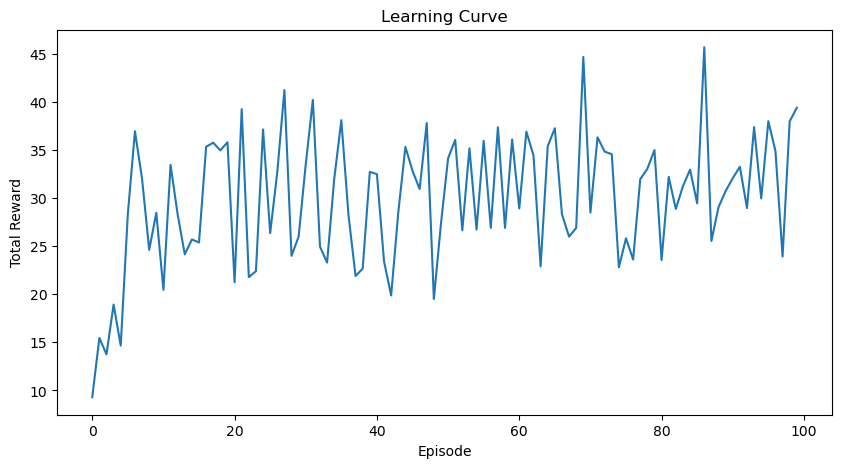


交易明細:
2019-11-18 00:00:00	Buy	11593.00	Enter Long
2019-11-22 00:00:00	Sell	11556.00	Enter Short
2019-11-25 00:00:00	Buy	11565.00	Enter Long
2019-11-28 00:00:00	Sell	11614.00	Enter Short
2019-12-05 00:00:00	Buy	11598.00	Enter Long
2019-12-10 00:00:00	Sell	11625.00	Enter Short
2019-12-11 00:00:00	Buy	11706.00	Enter Long
2020-01-03 00:00:00	Sell	12086.00	Enter Short
2020-01-13 00:00:00	Buy	12117.00	Enter Long
2020-01-15 00:00:00	Sell	12063.00	Enter Short


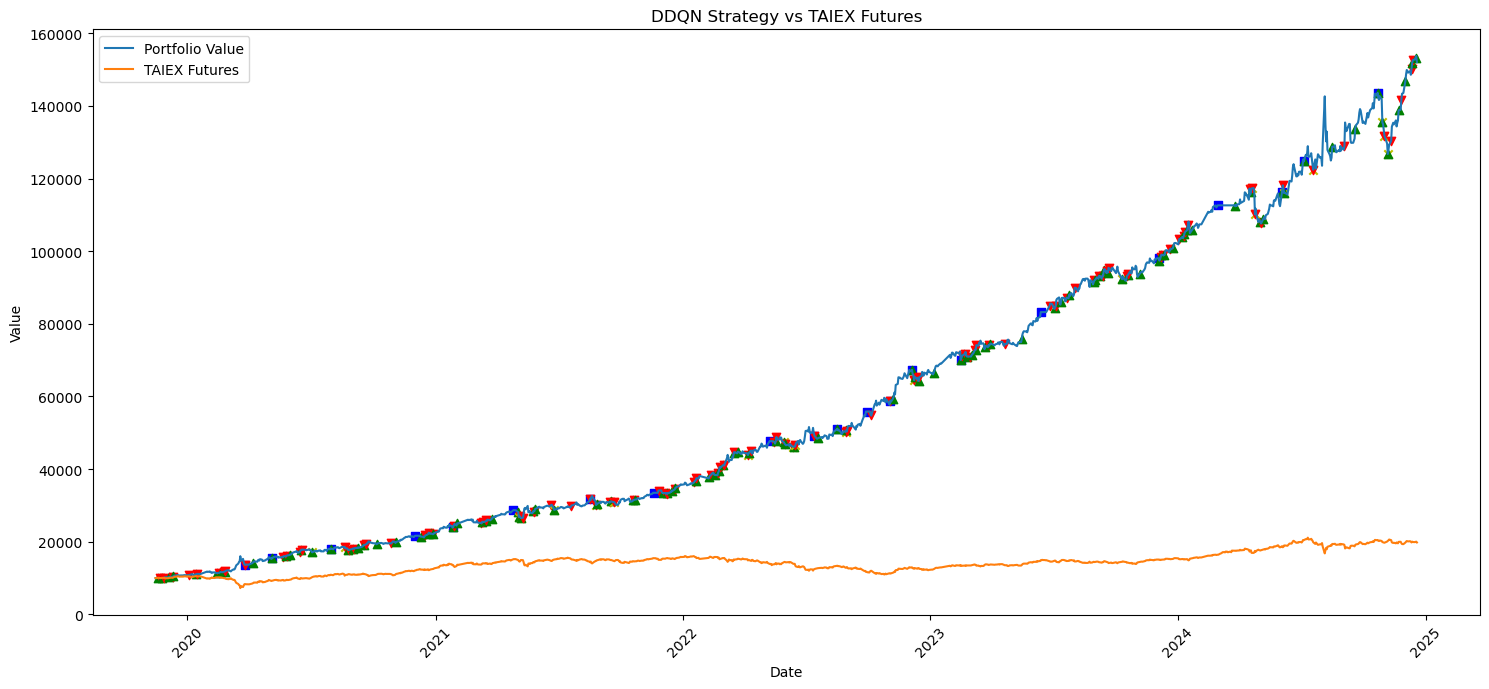


profit Performance Metrics:
Total Return (%): 1420.6227
Annualized Return (%): 73.8670
Sharpe Ratio: 2.8738
Max Drawdown (%): 14.9245
Win Rate (%): 55.4839


In [26]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size, strategy_type='profit'):
        self.state_size = state_size
        self.action_size = action_size
        self.strategy_type = strategy_type
        
        # 優化超參數
        self.memory = deque(maxlen=1000)  # 減少記憶體大小
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5  # 減少更新頻率
        self.batch_size = 64  # 增加批次大小以加快訓練
        
        # 創建網絡
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),  # 修正輸入層設置
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，計算技術指標"""
    try:
        # 讀取CSV文件
        data = pd.read_csv(file_path)
        
        # 檢查必要的列是否存在
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")

        # 打印數據信息
        print("原始數據資訊:")
        print(data.info())
        print("\n原始數據前5行:")
        print(data.head())
        
        # 確保所有價格列為數值類型
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            # 如果是字符串類型，移除逗號後轉換
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        # 處理Volume列（如果存在）
        if 'Volume' in data.columns:
            data['Volume'] = data['Volume'].astype(str).str.replace(',', '').astype(float)
        
        # 確保日期列格式
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 打印轉換後的數據信息
        print("\n數據轉換後資訊:")
        print(data.info())
        print("\n轉換後數據前5行:")
        print(data.head())
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # 計算RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 計算基差Z分數
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 計算波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
        
        # 計算趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """將市場數據轉換為狀態向量"""
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['Trend_Strength'],           # 趨勢強度
        row['Close'] / row['MA5'] - 1    # 價格相對MA5的位置
    ]
    return np.array(state)

def run_ddqn(data, strategy_type='profit', episodes=1000):
    state_size = 6  # 增加了一個特徵
    action_size = 3  # Buy, Sell, Hold
    agent = DDQNAgent(state_size, action_size, strategy_type)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 每個episode只使用部分數據進行訓練
        start_idx = random.randint(0, len(data) - 100)  # 隨機選擇起始點
        episode_data = data.iloc[start_idx:start_idx + 100]  # 使用100天的數據
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            # 更新持倉
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward_ddqn(action, row, position, holding_days, strategy_type)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_ddqn_strategy(agent, data, strategy_type='profit'):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 設定參數
    max_holding_days = {'profit': 20, 'winrate': 15, 'sharpe': 10}[strategy_type]
    stop_loss = {'profit': 0.03, 'winrate': 0.02, 'sharpe': 0.015}[strategy_type]
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        # 更新持倉天數
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
            holding_days = 0
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
            holding_days = 0
        
        # 持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 執行交易
        if action == 0 and position != "Long":  # Buy
            if row['RSI'] < 70:  # 簡化進場條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if row['RSI'] > 30:  # 簡化進場條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        # 更新組合價值
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def calculate_reward_ddqn(action, row, position, holding_days, strategy_type='profit'):
    """根據不同策略計算獎勵"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    if strategy_type == 'profit':
        # 獲利導向獎勵
        base_reward = 4.0 * return_value if position != "Cash" else 0
        trend_reward = 0.5 if (action_name == "Buy" and row['MA5'] > row['MA20'] and row['Basis_Z_Score'] < 0) or \
                            (action_name == "Sell" and row['MA5'] < row['MA20'] and row['Basis_Z_Score'] > 0) else 0
        holding_reward = 0.002 * holding_days if base_reward > 0 else 0
        basis_reward = 0.3 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                            (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
        return base_reward + trend_reward + holding_reward + basis_reward
    
    elif strategy_type == 'winrate':
        # 勝率導向獎勵
        if position != "Cash":
            base_reward = 2.0 if return_value > 0 else -1.0
        else:
            base_reward = 0
            
        basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                            (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
        tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                            (action_name == "Sell" and row['RSI'] > 70) else 0
        loss_control = 0.3 if -0.01 <= return_value < 0 else 0
        return base_reward + basis_reward + tech_reward + loss_control
    
    else:  # sharpe
        # 夏普比率導向獎勵
        volatility = row['Volatility']
        risk_adjusted_return = return_value / (volatility ** 0.5) if volatility > 0 else 0
        base_reward = 3.0 * risk_adjusted_return if position != "Cash" else 0
        trend_reward = 0.5 * row['Trend_Strength'] if position != "Cash" else 0
        basis_reward = 0.5 if volatility < row['Volatility_MA'] and \
                            ((action_name == "Buy" and row['Basis_Z_Score'] < -1) or \
                             (action_name == "Sell" and row['Basis_Z_Score'] > 1)) else 0
        vol_reward = 0.2 if volatility < row['Volatility_MA'] else -0.1
        return base_reward + trend_reward + basis_reward + vol_reward

def calculate_performance_metrics(portfolio_values, benchmark_values):
    """計算績效指標"""
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

def plot_results(data, portfolio_values, trades):
    """繪製結果圖表"""
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('DDQN Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    """繪製學習曲線"""
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置較小的批次大小和更快的學習頻率
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        # 只測試profit策略，減少訓練時間
        strategy = 'profit'
        print(f"\n訓練 {strategy} 策略:")
        
        # 減少episode數量進行測試
        trained_agent, rewards_history = run_ddqn(train_data, strategy, episodes=100)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_ddqn_strategy(trained_agent, test_data, strategy)
        
        print("\n交易明細:")
        for trade in trades[:10]:  # 只顯示前10筆交易
            print(f"{trade[1]}\t{trade[0]}\t{trade[2]:.2f}\t{trade[3]}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\n{strategy} Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")

In [28]:
print("\n完整交易明細:")
print("時間\t\t\t類型\t\t價格\t\t說明")
print("-" * 70)
for trade in trades:
    print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
print(f"\n總交易筆數: {len(trades)}")


完整交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-18 00:00:00	Buy		11593.00		Enter Long
2019-11-22 00:00:00	Sell		11556.00		Enter Short
2019-11-25 00:00:00	Buy		11565.00		Enter Long
2019-11-28 00:00:00	Sell		11614.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2019-12-10 00:00:00	Sell		11625.00		Enter Short
2019-12-11 00:00:00	Buy		11706.00		Enter Long
2020-01-03 00:00:00	Sell		12086.00		Enter Short
2020-01-13 00:00:00	Buy		12117.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-02-14 00:00:00	Buy		11812.00		Enter Long
2020-02-17 00:00:00	Sell		11770.00		Enter Short
2020-02-19 00:00:00	Buy		11760.00		Enter Long
2020-02-24 00:00:00	Sell		11508.00		Enter Short
2020-02-25 00:00:00	Buy		11542.00		Enter Long
2020-02-26 00:00:00	Sell		11421.00		Enter Short
2020-03-26 00:00:00	TimeExit		9638.00		Exit Short
2020-03-26 00:00:00	Sell		9638.00		Enter Short
2020-04-06 00:00:00	Buy		9826.00		Enter Long
2020-05-05


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:37:30<00:00, 58.50s/it]


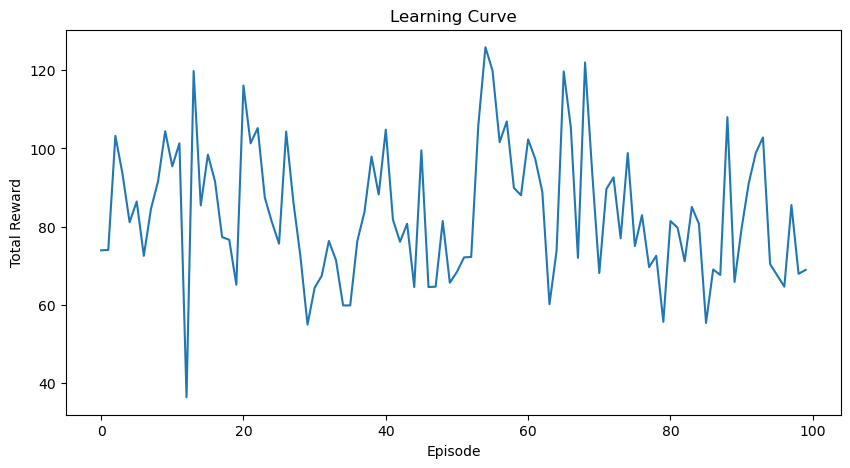


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-26 00:00:00	Buy		11618.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2019-12-26 00:00:00	TimeExit		12009.00		Exit Long
2019-12-31 00:00:00	Sell		11995.00		Enter Short
2020-01-09 00:00:00	Buy		11968.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-20 00:00:00	Buy		12111.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-06 00:00:00	Buy		11741.00		Enter Long
2020-02-10 00:00:00	StopLoss		11402.00		Exit Long
2020-02-11 00:00:00	Buy		11666.00		Enter Long
2020-02-25 00:00:00	StopLoss		11386.00		Exit Long
2020-03-24 00:00:00	Buy		9193.00		Enter Long
2020-04-16 00:00:00	TimeExit		10302.00		Exit Long
2020-04-22 00:00:00	Sell		10225.00		Enter Short
2020-04-27 00:00:00	StopLoss		10567.00		Exit Short
2020-05-04 00:00:00	Sell		10615.00		Enter Short
2020-05-05 00:00:00	Buy		10725.00		Enter Lon

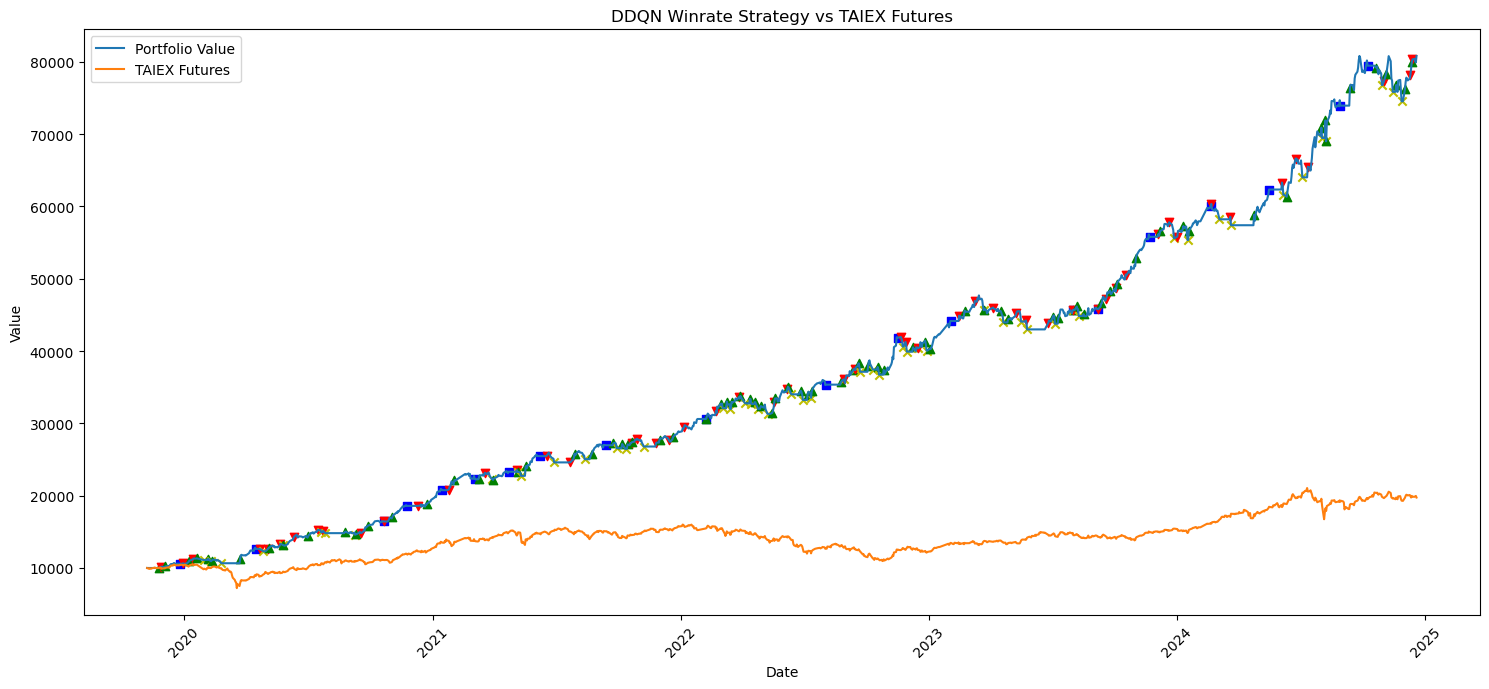


Winrate Strategy Performance Metrics:
Total Return (%): 707.8523
Annualized Return (%): 52.6345
Sharpe Ratio: 2.8645
Max Drawdown (%): 9.8587
Win Rate (%): 42.6506


In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對winrate策略優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        # 創建網絡
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，計算技術指標"""
    try:
        data = pd.read_csv(file_path)
        
        # 檢查必要的列是否存在
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        # 確保所有價格列為數值類型
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        # 確保日期列格式
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # 計算RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 計算基差相關指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 計算回報率與波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """將市場數據轉換為狀態向量，針對winrate策略優化特徵"""
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['MA5'] / row['MA20'] - 1,    # MA交叉狀態
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """針對winrate策略的獎勵函數"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵：重點關注勝率
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                        (action_name == "Sell" and row['RSI'] > 70) else 0
    
    # 虧損控制獎勵（鼓勵小虧損）
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def run_ddqn(data, episodes=100):
    state_size = 6
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 每個episode使用部分數據
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # Winrate策略的風險控制參數
    max_holding_days = 15  # 縮短最大持倉時間
    stop_loss = 0.02      # 收緊止損
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
            holding_days = 0
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
            holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行 - 針對winrate策略優化的進場條件
        if action == 0 and position != "Long":  # Buy
            if row['RSI'] < 60 and row['Close'] > row['MA5']:  # 更保守的買入條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if row['RSI'] > 40 and row['Close'] < row['MA5']:  # 更保守的賣出條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        # 更新組合價值
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('DDQN Winrate Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置較小的批次大小和更快的學習頻率
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4114
訓練資料筆數: 2879
測試資料筆數: 1235
--------------------------------------------------

開始訓練 Winrate 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:32:02<00:00, 55.23s/it]


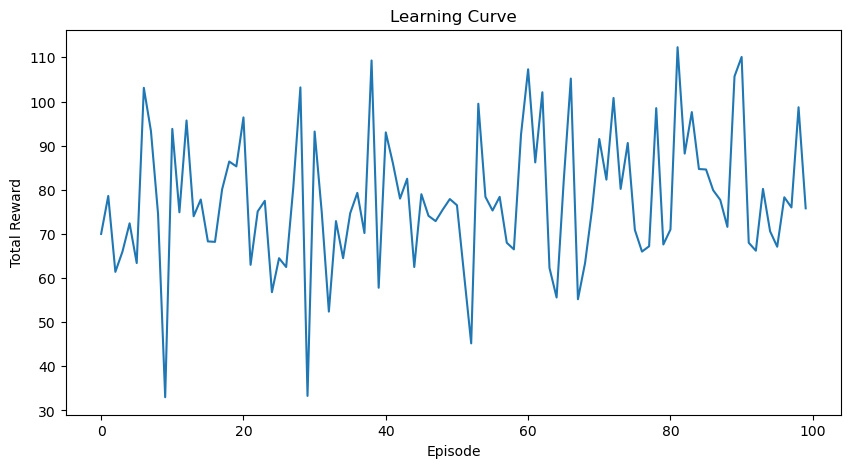


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-12-02 00:00:00	Sell		11502.00		Enter Short
2019-12-09 00:00:00	StopLoss		11699.00		Exit Short
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-07 00:00:00	TimeExit		11871.00		Exit Short
2020-02-20 00:00:00	Sell		11715.00		Enter Short
2020-03-10 00:00:00	TimeExit		10984.00		Exit Short
2020-04-13 00:00:00	Sell		10073.00		Enter Short
2020-04-14 00:00:00	StopLoss		10355.00		Exit Short
2020-04-21 00:00:00	Sell		10198.00		Enter Short
2020-04-23 00:00:00	StopLoss		10402.00		Exit Short
2020-04-23 00:00:00	Sell		10292.00		Enter Short
2020-04-27 00:00:00	StopLoss		10567.00		Exit Short
2020-05-12 00:00:00	Sell		10865.00		Enter Short
2020-05-27 00:00:00	StopLoss		11037.00		Exit Short
2020-06-12 00:00:00	Sell		11395.00		Enter Short
2020-06-17 00:00:00	StopLoss		11568.00		Exit Short
2020-07-10 00:00:00	Sell		11999.00		Enter Short
2020-07-13 00:00:00	StopLoss		12210.00		Exit Short
2020-08-03 00:0

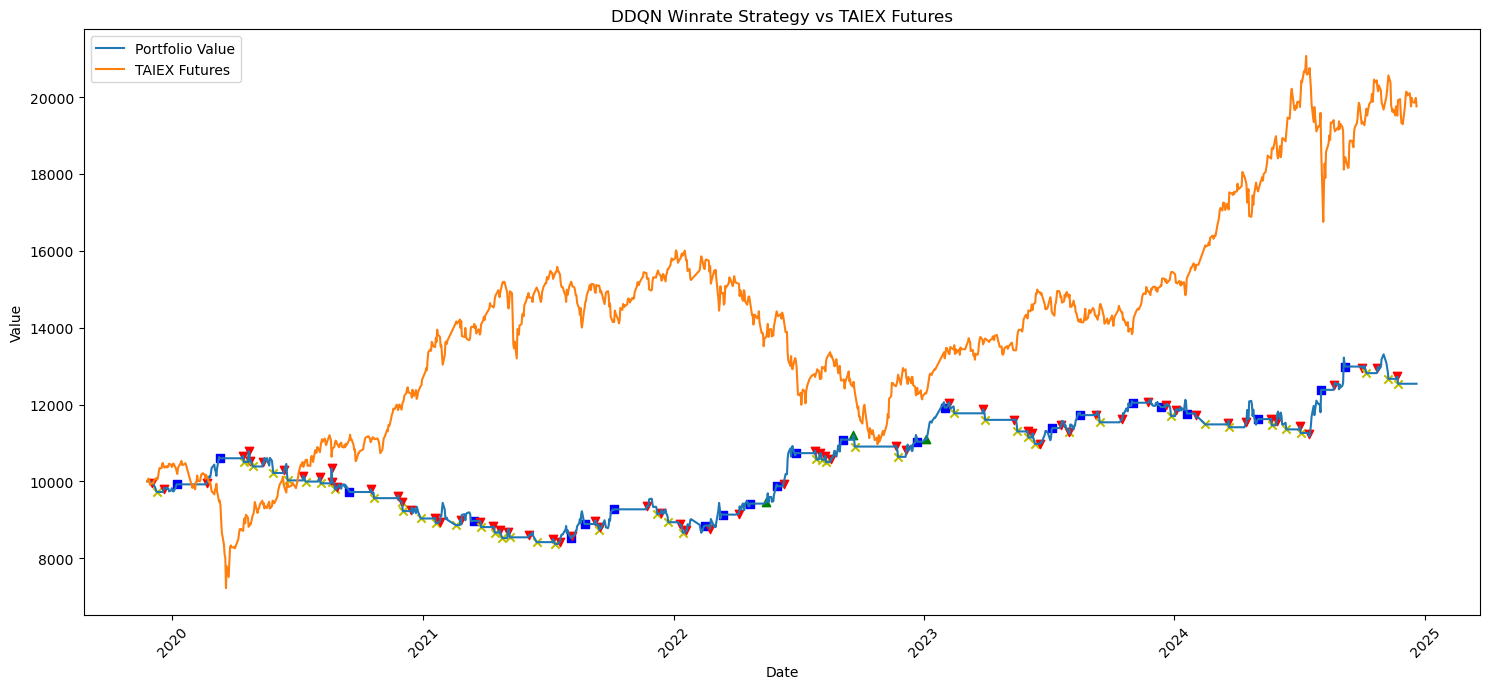


Winrate Strategy Performance Metrics:
Total Return (%): 25.3997
Annualized Return (%): 4.7306
Sharpe Ratio: 0.4354
Max Drawdown (%): 22.3729
Win Rate (%): 20.8266


In [67]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對winrate策略優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        # 創建網絡
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        # 基本數據處理
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        # 處理價格數據
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        # 處理日期
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        data['MA60'] = data['Close'].rolling(window=60).mean()
        
        # RSI及其變化率
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        data['RSI_Change'] = data['RSI'].diff()
        
        # 波動率指標
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
        
        # 成交量指標
        # 如果存在Volume列，則計算MA，否則使用Close的變化率作為替代
        if 'Volume' in data.columns:
            try:
                data['Volume'] = data['Volume'].astype(str).str.replace(',', '').astype(float)
                data['Volume_MA'] = data['Volume'].rolling(window=20).mean()
                data['Volume_MA_Ratio'] = data['Volume'] / data['Volume_MA']
            except Exception as e:
                print(f"處理Volume時出錯: {str(e)}")
                data['Volume_MA_Ratio'] = abs(data['Return']) / data['Return'].rolling(window=20).mean()
        else:
            # 如果沒有Volume資料，使用價格變化率的相對強度作為替代
            data['Volume_MA_Ratio'] = abs(data['Return']) / data['Return'].rolling(window=20).mean()
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """將市場數據轉換為狀態向量，針對winrate策略優化特徵"""
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['MA5'] / row['MA20'] - 1,    # MA交叉狀態
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """針對winrate策略的獎勵函數"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵：重點關注勝率
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                        (action_name == "Sell" and row['RSI'] > 70) else 0
    
    # 虧損控制獎勵（鼓勵小虧損）
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def run_ddqn(data, episodes=100):
    state_size = 6
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 每個episode使用部分數據
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # Winrate策略的風險控制參數
    max_holding_days = 12  # 縮短最大持倉時間
    stop_loss = 0.015      # 收緊止損
    take_profit = 0.03     # 停利動作
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
            holding_days = 0
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
            holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行 - 針對winrate策略優化的進場條件
        if action == 0 and position != "Long":  # Buy
            if (row['RSI'] >= 30 and row['RSI'] <= 45 and  # RSI在低檔區域
                row['Close'] > row['MA5'] and              # 價格在短期均線上方
                row['Volume_MA_Ratio'] > 1.2 and           # 成交量確認
                row['Basis_Z_Score'] < -1.0):              # 基差確認  # 更保守的買入條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if row['RSI'] > 40 and row['Close'] < row['MA5']:  # 更保守的賣出條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        # 更新組合價值
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('DDQN Winrate Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置較小的批次大小和更快的學習頻率
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate v2 策略:


Training Progress: 100%|██████████████████████████████████████████████████████████| 100/100 [3:53:47<00:00, 140.28s/it]


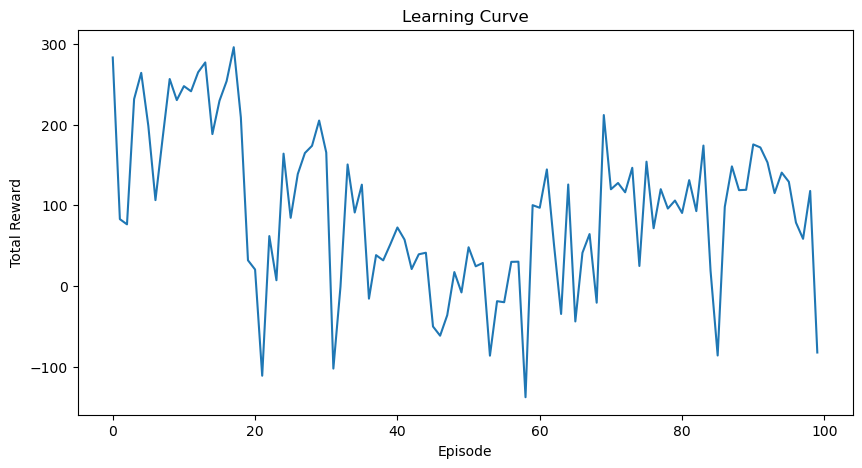


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-11 00:00:00	Sell		11437.00		Enter Short
2019-11-25 00:00:00	TimeExit		11565.00		Exit Short
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-09 00:00:00	StopLoss		11699.00		Exit Short
2019-12-19 00:00:00	Sell		12030.00		Enter Short
2020-01-03 00:00:00	TimeExit		12086.00		Exit Short
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-30 00:00:00	TakeProfit		11366.00		Exit Short
2020-02-20 00:00:00	Sell		11715.00		Enter Short
2020-02-25 00:00:00	TakeProfit		11386.00		Exit Short
2020-03-24 00:00:00	Buy		9193.00		Enter Long
2020-03-25 00:00:00	TakeProfit		9624.00		Exit Long
2020-04-13 00:00:00	Sell		10073.00		Enter Short
2020-04-14 00:00:00	StopLoss		10355.00		Exit Short
2020-04-21 00:00:00	Sell		10198.00		Enter Short
2020-04-23 00:00:00	StopLoss		10402.00		Exit Short
2020-04-23 00:00:00	Sell		10292.00		Enter Short
2020-04-27 00:00:00	StopLoss		10567.00		Exit Short
2020-05-04 00:

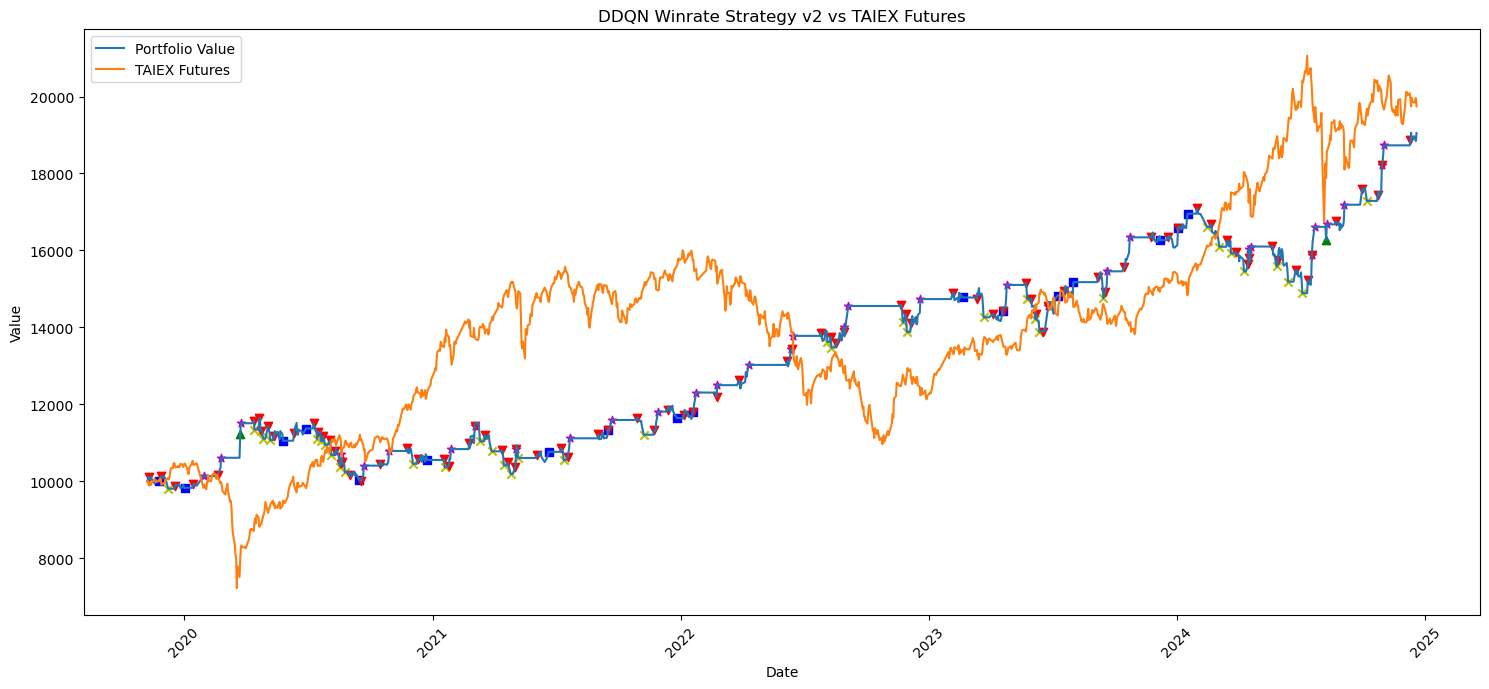


Winrate Strategy Performance Metrics:
Total Return (%): 90.4959
Annualized Return (%): 13.9335
Sharpe Ratio: 1.0878
Max Drawdown (%): 14.0033
Win Rate (%): 21.9277


In [77]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 調整超參數
        self.memory = deque(maxlen=10000)  # 增加記憶體大小
        self.gamma = 0.95                  # 降低gamma值
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.99          # 減慢探索衰減
        self.learning_rate = 0.001         # 增加學習率
        self.update_target_frequency = 10   # 增加更新頻率
        self.batch_size = 32               # 減小批次大小
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(128, activation='relu'),
            BatchNormalization(),
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.2),
            Dense(32, activation='relu'),
            BatchNormalization(),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 基礎技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA10'] = data['Close'].rolling(window=10).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 動量指標
        data['ROC'] = data['Close'].pct_change(5)
        
        # 波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['ATR'] = pd.DataFrame({
            'H-L': data['High'] - data['Low'],
            'H-PC': abs(data['High'] - data['Close'].shift(1)),
            'L-PC': abs(data['Low'] - data['Close'].shift(1))
        }).max(axis=1)
        
        # 成交量替代指標
        data['Price_Range'] = (data['High'] - data['Low']) / data['Close']
        data['Price_Range_MA'] = data['Price_Range'].rolling(window=20).mean()
        data['Volume_Indicator'] = data['Price_Range'] / data['Price_Range_MA']
        
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    state = [
        row['Close'] / row['MA20'] - 1,     # 價格趨勢
        row['RSI'] / 100,                    # RSI
        row['Trend_Strength'],               # 趨勢強度
        row['Volatility'],                   # 波動率
        row['ROC'],                          # 動量
        row['ATR'] / row['Close'],           # 標準化ATR
        row['Price_Range'],                  # 價格區間
        row['Volume_Indicator']              # 成交量指標
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵
    if position != "Cash":
        if return_value > 0:
            base_reward = 2.0 + return_value  # 減小獲利時的倍數
        else:
            base_reward = -1.0 + return_value  # 減小虧損時的倍數
    else:
        base_reward = 0
    
    # 趨勢獎勵
    trend_reward = 0.5 if (action_name == "Buy" and row['MA5'] > row['MA20']) or \
                       (action_name == "Sell" and row['MA5'] < row['MA20']) else 0
    
    # RSI獎勵：更寬鬆的條件
    rsi_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 50) or \
                      (action_name == "Sell" and row['RSI'] > 50) else 0
    
    # 波動率懲罰
    vol_penalty = -0.2 if row['Volatility'] > row['Price_Range_MA'] else 0
    
    # 持倉時間懲罰：更早開始懲罰
    time_penalty = -0.1 * (holding_days / 5) if holding_days > 5 else 0
    
    total_reward = base_reward + trend_reward + rsi_reward + vol_penalty + time_penalty
    
    # 限制獎勵範圍
    return np.clip(total_reward, -3, 3)

def run_ddqn(data, episodes=100):
    state_size = 8  # 更新為新的狀態維度
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 使用較長的訓練片段
        start_idx = random.randint(0, len(data) - 250)
        episode_data = data.iloc[start_idx:start_idx + 250]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 調整風險參數
    max_holding_days = 10     # 更短的最大持倉時間
    stop_loss = 0.02         # 適中的止損
    take_profit = 0.025      # 較低的獲利目標
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 止損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行：簡化條件
        if action == 0 and position != "Long":  # Buy
            if (row['RSI'] < 50 and                       # 更寬鬆的RSI條件
                row['Close'] > row['MA5'] and            # 短期均線支撐
                row['Trend_Strength'] > 0.001):          # 確認趨勢強度
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (row['RSI'] > 50 and                      # 更寬鬆的RSI條件
                row['Close'] < row['MA5'] and            # 短期均線阻力
                row['Trend_Strength'] > 0.001):          # 確認趨勢強度
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades


def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v2 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v2 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")



資料集大小:
總資料筆數: 4114
訓練資料筆數: 2879
測試資料筆數: 1235
--------------------------------------------------

開始訓練 Winrate v3 策略:


Training Progress: 100%|██████████████████████████████████████████████████████████| 100/100 [3:09:08<00:00, 113.48s/it]


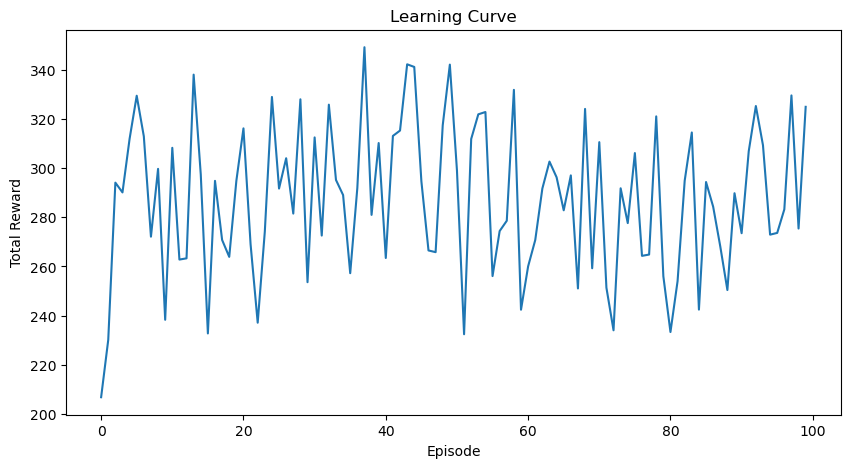


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2020-09-09 00:00:00	Sell		12598.00		Enter Short
2020-09-15 00:00:00	StopLoss		12855.00		Exit Short

總交易筆數: 2


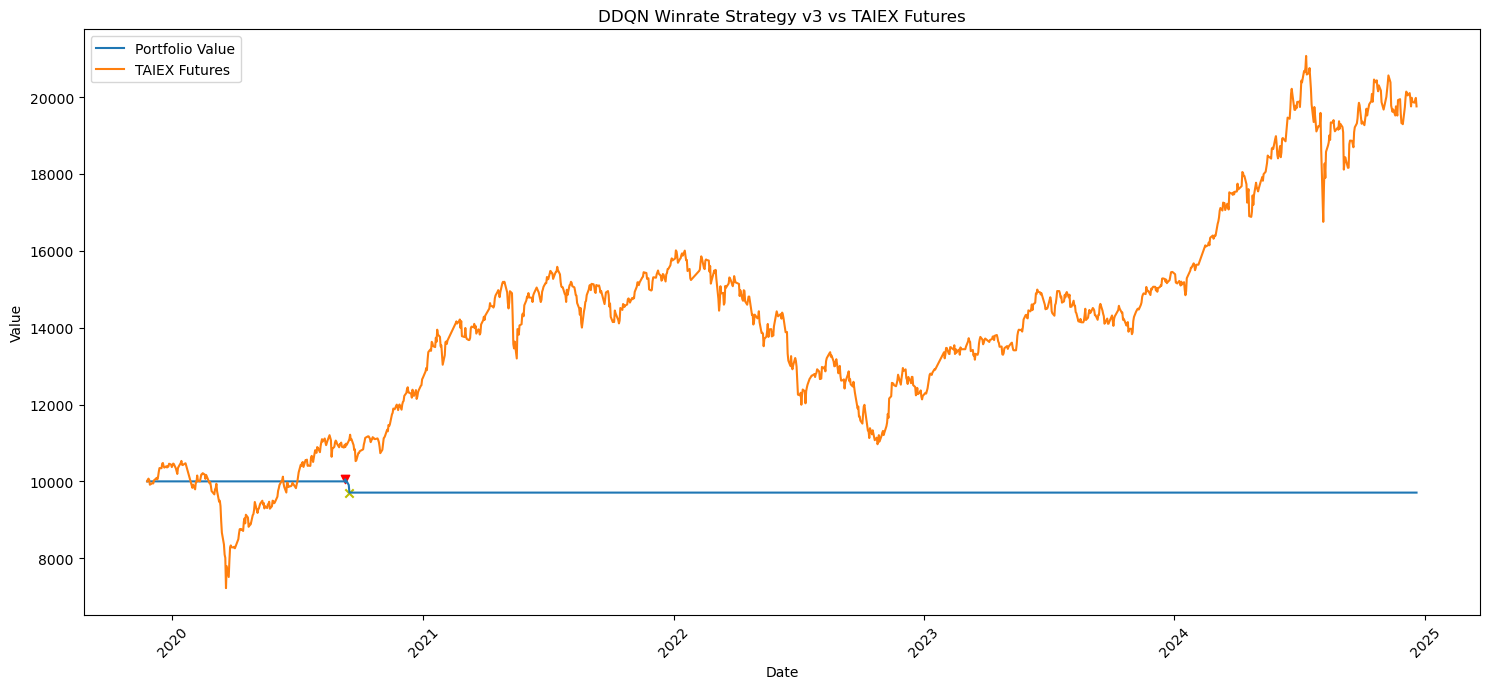


Winrate Strategy Performance Metrics:
Total Return (%): -2.9238
Annualized Return (%): -0.6042
Sharpe Ratio: -0.5425
Max Drawdown (%): 3.4497
Win Rate (%): 0.1621


In [81]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 調整超參數回到較穩定的配置
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995  # 改回較慢的衰減
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64  # 改回較大的batch size
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        # 簡化網絡結構，避免過擬合
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA10'] = data['Close'].rolling(window=10).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        data['MA60'] = data['Close'].rolling(window=60).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # 波動率指標
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        # 移動平均交叉
        data['MA_Cross'] = (data['MA5'] > data['MA20']).astype(int)
        data['MA_Cross_Change'] = data['MA_Cross'].diff()
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    state = [
        row['Close'] / row['MA20'] - 1,        # 價格相對MA20
        row['RSI'] / 100,                      # RSI標準化
        row['Trend_Strength'],                 # 趨勢強度
        row['Volatility'],                     # 波動率
        row['MA5'] / row['MA20'] - 1,         # MA交叉狀態
        row['MA_Cross']                        # MA交叉信號
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵：固定值而不是根據return_value浮動
    if position != "Cash":
        if return_value > 0:
            base_reward = 2.0
        else:
            base_reward = -1.0
    else:
        base_reward = 0
    
    # 趨勢獎勵
    trend_reward = 1.0 if (action_name == "Buy" and row['MA5'] > row['MA20']) or \
                       (action_name == "Sell" and row['MA5'] < row['MA20']) else 0
    
    # RSI獎勵: 收緊獎勵區間
    rsi_reward = 1.0 if (action_name == "Buy" and 30 <= row['RSI'] <= 45) or \
                      (action_name == "Sell" and 55 <= row['RSI'] <= 70) else 0
    
    # 交叉確認獎勵
    cross_reward = 0.5 if (action_name == "Buy" and row['MA_Cross_Change'] == 1) or \
                       (action_name == "Sell" and row['MA_Cross_Change'] == -1) else 0
    
    # 持倉時間懲罰
    time_penalty = -0.1 * (holding_days / 10) if holding_days > 10 else 0
    
    total_reward = base_reward + trend_reward + rsi_reward + cross_reward + time_penalty
    
    return np.clip(total_reward, -3, 3)  # 限制獎勵範圍

def run_ddqn(data, episodes=100):
    state_size = 6  # 更新狀態維度
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 使用較長的訓練片段
        start_idx = random.randint(0, len(data) - 200)
        episode_data = data.iloc[start_idx:start_idx + 200]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 調整風險參數
    max_holding_days = 15    # 延長持倉時間
    stop_loss = 0.02        # 維持2%止損
    take_profit = 0.03      # 提高止盈目標
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 止損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行
        if action == 0 and position != "Long":  # Buy
            if (30 <= row['RSI'] <= 45 and                  # 收緊RSI範圍
                row['Close'] > row['MA5'] and              # 價格在MA5上方
                row['MA5'] > row['MA20'] and              # MA5上穿MA20
                row['Trend_Strength'] > 0.002):           # 確認趨勢強度
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (55 <= row['RSI'] <= 70 and                  # 收緊RSI範圍
                row['Close'] < row['MA5'] and              # 價格在MA5下方
                row['MA5'] < row['MA20'] and              # MA5下穿MA20
                row['Trend_Strength'] > 0.002):           # 確認趨勢強度
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        value = portfolio_values[data.index.get_loc(trade[1])]
        if trade[0] == "Buy":
            plt.scatter(trade[1], value, color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], value, color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], value, color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], value, color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], value, color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v3 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v3 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")



資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate v4 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [2:08:26<00:00, 77.06s/it]


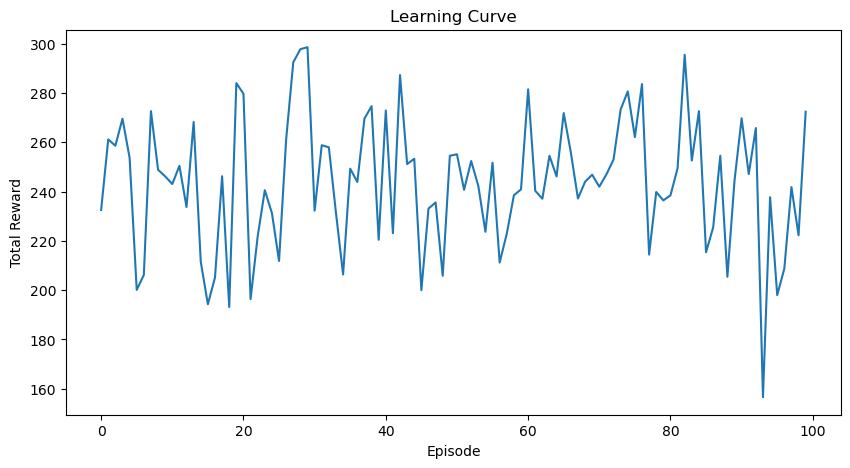


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-25 00:00:00	Buy		11565.00		Enter Long
2019-12-11 00:00:00	TimeExit		11706.00		Exit Long
2020-01-06 00:00:00	Buy		11950.00		Enter Long
2020-01-08 00:00:00	StopLoss		11697.00		Exit Long
2020-01-17 00:00:00	Buy		12072.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-13 00:00:00	Buy		11774.00		Enter Long
2020-02-24 00:00:00	StopLoss		11476.00		Exit Long
2020-03-30 00:00:00	Buy		9576.00		Enter Long
2020-04-06 00:00:00	TakeProfit		9860.00		Exit Long
2020-04-06 00:00:00	Buy		9826.00		Enter Long
2020-04-08 00:00:00	TakeProfit		10135.00		Exit Long
2020-05-29 00:00:00	Buy		10922.00		Enter Long
2020-06-03 00:00:00	TakeProfit		11299.00		Exit Long
2020-06-30 00:00:00	Buy		11469.00		Enter Long
2020-07-03 00:00:00	TakeProfit		11850.00		Exit Long
2020-09-02 00:00:00	Buy		12691.00		Enter Long
2020-09-09 00:00:00	StopLoss		12434.00		Exit Long
2020-09-21 00:00:00	Buy		12659.00		En

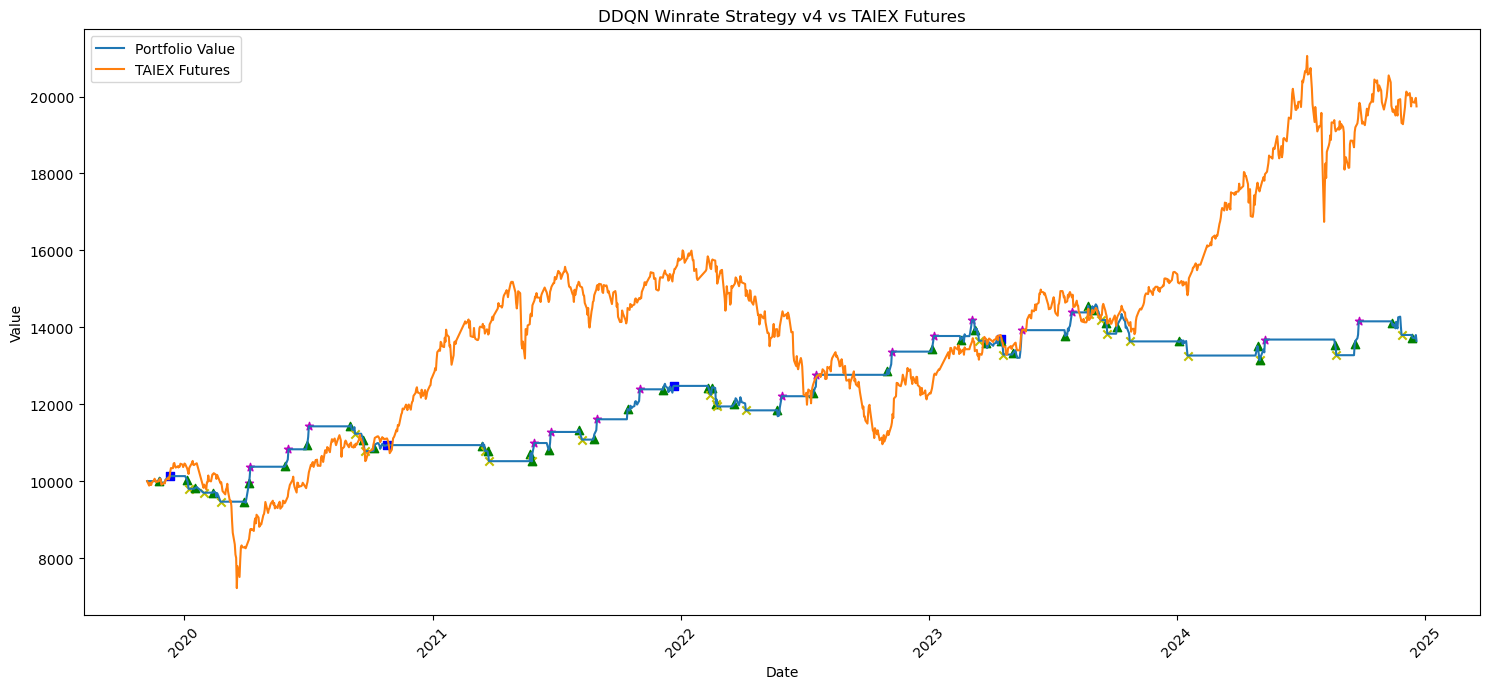


Winrate Strategy Performance Metrics:
Total Return (%): 36.4591
Annualized Return (%): 6.4942
Sharpe Ratio: 0.8080
Max Drawdown (%): 9.9789
Win Rate (%): 11.8072


In [85]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 優化的超參數
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.99          # 減慢探索衰減速度
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 32               # 減小批次大小
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(64, activation='relu'),  # 增加網絡容量
            Dense(32, activation='relu'),
            Dense(32, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='huber', optimizer=Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 基礎技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA10'] = data['Close'].rolling(window=10).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # 動能指標
        data['ROC'] = data['Close'].pct_change(10)  # 10日變化率
        
        # 波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        # MA交叉狀態
        data['MA5_Cross_10'] = (data['MA5'] > data['MA10']).astype(int)
        data['MA5_Cross_20'] = (data['MA5'] > data['MA20']).astype(int)
        
        # 價格位置
        data['Price_to_MA5'] = data['Close'] / data['MA5'] - 1
        data['Price_to_MA20'] = data['Close'] / data['MA20'] - 1
        
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    state = [
        row['Price_to_MA5'],              # 價格相對MA5的位置
        row['Price_to_MA20'],             # 價格相對MA20的位置
        row['RSI'] / 100,                 # RSI標準化
        row['Trend_Strength'],            # 趨勢強度
        row['Volatility'],                # 波動率
        row['ROC'],                       # 價格動能
        row['MA5_Cross_10'],              # MA5與MA10的交叉狀態
        row['MA5_Cross_20'],              # MA5與MA20的交叉狀態
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵：增加正向獎勵
    if position != "Cash":
        if return_value > 0:
            base_reward = 3.0 + return_value * 2  # 增加獲利時的獎勵
        else:
            base_reward = -1.0 + return_value     # 保持較小的懲罰
    else:
        base_reward = 0
    
    # 趨勢獎勵：增加獎勵力度
    trend_reward = 1.5 if (action_name == "Buy" and row['MA5_Cross_10'] == 1 and row['MA5_Cross_20'] == 1) or \
                       (action_name == "Sell" and row['MA5_Cross_10'] == 0 and row['MA5_Cross_20'] == 0) else 0
    
    # RSI獎勵：放寬條件
    rsi_reward = 1.0 if (action_name == "Buy" and 30 <= row['RSI'] <= 50) or \
                      (action_name == "Sell" and 50 <= row['RSI'] <= 70) else 0
    
    # 動能獎勵
    momentum_reward = 0.5 if (action_name == "Buy" and row['ROC'] > 0) or \
                          (action_name == "Sell" and row['ROC'] < 0) else 0
    
    # 持倉時間懲罰：更早開始懲罰
    time_penalty = -0.2 * (holding_days / 8) if holding_days > 8 else 0
    
    total_reward = base_reward + trend_reward + rsi_reward + momentum_reward + time_penalty
    
    # 限制獎勵範圍
    return np.clip(total_reward, -3, 3)

def run_ddqn(data, episodes=100):
    state_size = 8  # 更新狀態維度
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 使用較長的訓練片段
        start_idx = random.randint(0, len(data) - 150)
        episode_data = data.iloc[start_idx:start_idx + 150]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 調整風險參數
    max_holding_days = 12     # 縮短持倉時間
    stop_loss = 0.015        # 收緊止損
    take_profit = 0.025      # 降低止盈目標
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 止損檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行
        if action == 0 and position != "Long":  # Buy
            if (30 <= row['RSI'] <= 50 and                     # 放寬RSI區間
                ((row['Close'] > row['MA5'] and row['MA5'] > row['MA10']) or   # 短期趨勢
                 (row['MA5'] > row['MA20'] and row['Trend_Strength'] > 0.001)) and  # 長期趨勢
                row['ROC'] > -0.01):                           # 動能確認
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (50 <= row['RSI'] <= 70 and                     # 放寬RSI區間
                ((row['Close'] < row['MA5'] and row['MA5'] < row['MA10']) or   # 短期趨勢
                 (row['MA5'] < row['MA20'] and row['Trend_Strength'] > 0.001)) and  # 長期趨勢
                row['ROC'] < 0.01):                            # 動能確認
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        value = portfolio_values[data.index.get_loc(trade[1])]
        if trade[0] == "Buy":
            plt.scatter(trade[1], value, color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], value, color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], value, color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], value, color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], value, color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v4 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v4 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate v1.1 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:28:49<00:00, 53.30s/it]


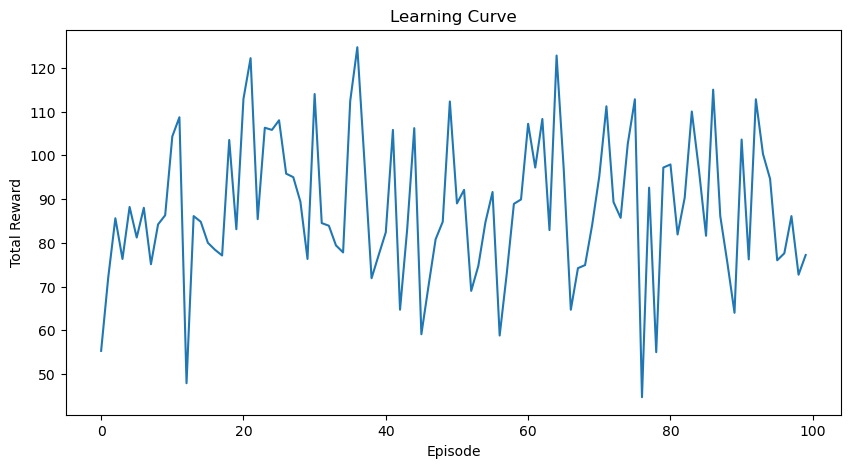


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-15 00:00:00	Buy		11532.00		Enter Long
2019-12-06 00:00:00	TimeExit		11612.00		Exit Long
2020-02-11 00:00:00	Buy		11666.00		Enter Long
2020-02-25 00:00:00	StopLoss		11386.00		Exit Long
2020-04-06 00:00:00	Buy		9826.00		Enter Long
2020-04-08 00:00:00	TakeProfit		10135.00		Exit Long
2020-05-04 00:00:00	Sell		10615.00		Enter Short
2020-05-07 00:00:00	StopLoss		10877.00		Exit Short
2020-05-19 00:00:00	Buy		10872.00		Enter Long
2020-05-25 00:00:00	StopLoss		10651.00		Exit Long
2020-08-14 00:00:00	Buy		12788.00		Enter Long
2020-08-20 00:00:00	StopLoss		12067.00		Exit Long
2020-09-08 00:00:00	Buy		12667.00		Enter Long
2020-09-09 00:00:00	StopLoss		12434.00		Exit Long
2020-09-10 00:00:00	Buy		12699.00		Enter Long
2020-09-23 00:00:00	StopLoss		12441.00		Exit Long
2020-10-07 00:00:00	Buy		12755.00		Enter Long
2020-10-29 00:00:00	StopLoss		12504.00		Exit Long
2020-11-09 00:00:00	Buy		13121.00		Ent

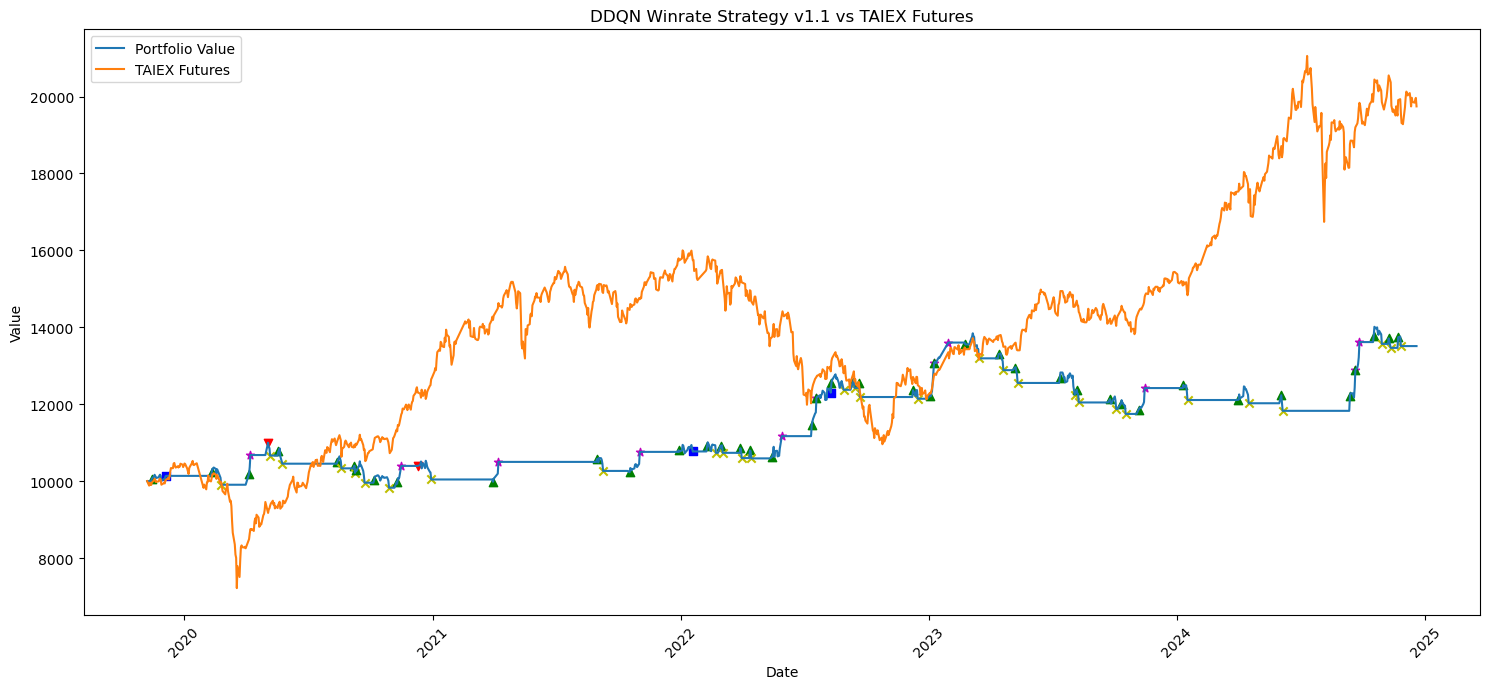


Winrate Strategy Performance Metrics:
Total Return (%): 35.1085
Annualized Return (%): 6.2800
Sharpe Ratio: 0.6761
Max Drawdown (%): 15.1486
Win Rate (%): 14.4578


In [87]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 保持原始的超參數設置
        self.memory = deque(maxlen=1000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，計算技術指標"""
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        # 確保數值類型
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['MA5'] / row['MA20'] - 1,    # MA交叉狀態
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """保持原始的獎勵函數"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                        (action_name == "Sell" and row['RSI'] > 70) else 0
    
    # 虧損控制獎勵
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def run_ddqn(data, episodes=100):
    state_size = 6
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 優化風險參數
    max_holding_days = 15    # 保持原值
    stop_loss = 0.018       # 調整至1.8%
    take_profit = 0.03      # 新增3%止盈
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損和止盈檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 優化的進場條件
        if action == 0 and position != "Long":  # Buy
            if (35 <= row['RSI'] <= 65 and               # 調整RSI範圍
                row['Close'] > row['MA5'] and           # 保持價格>MA5
                row['Basis_Z_Score'] < -1.0):           # 放寬基差條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (35 <= row['RSI'] <= 65 and               # 調整RSI範圍
                row['Close'] < row['MA5'] and           # 保持價格<MA5
                row['Basis_Z_Score'] > 1.0):            # 放寬基差條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v1.1 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v1.1 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate v1.2 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [2:30:31<00:00, 90.31s/it]


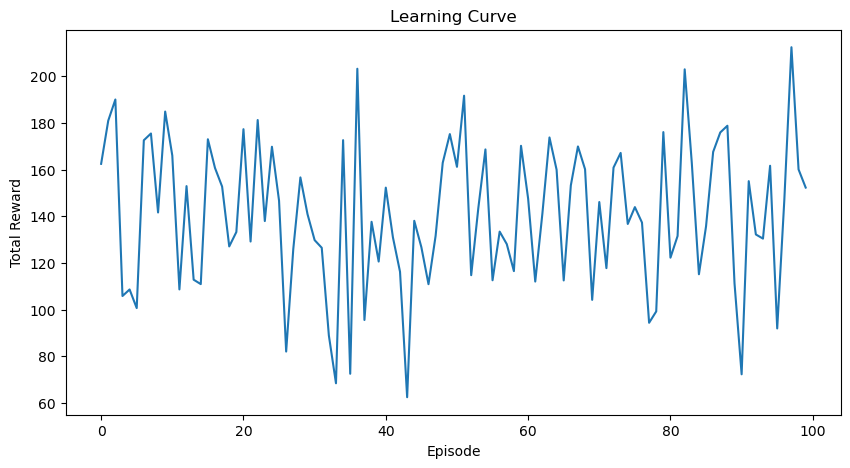


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------

總交易筆數: 0


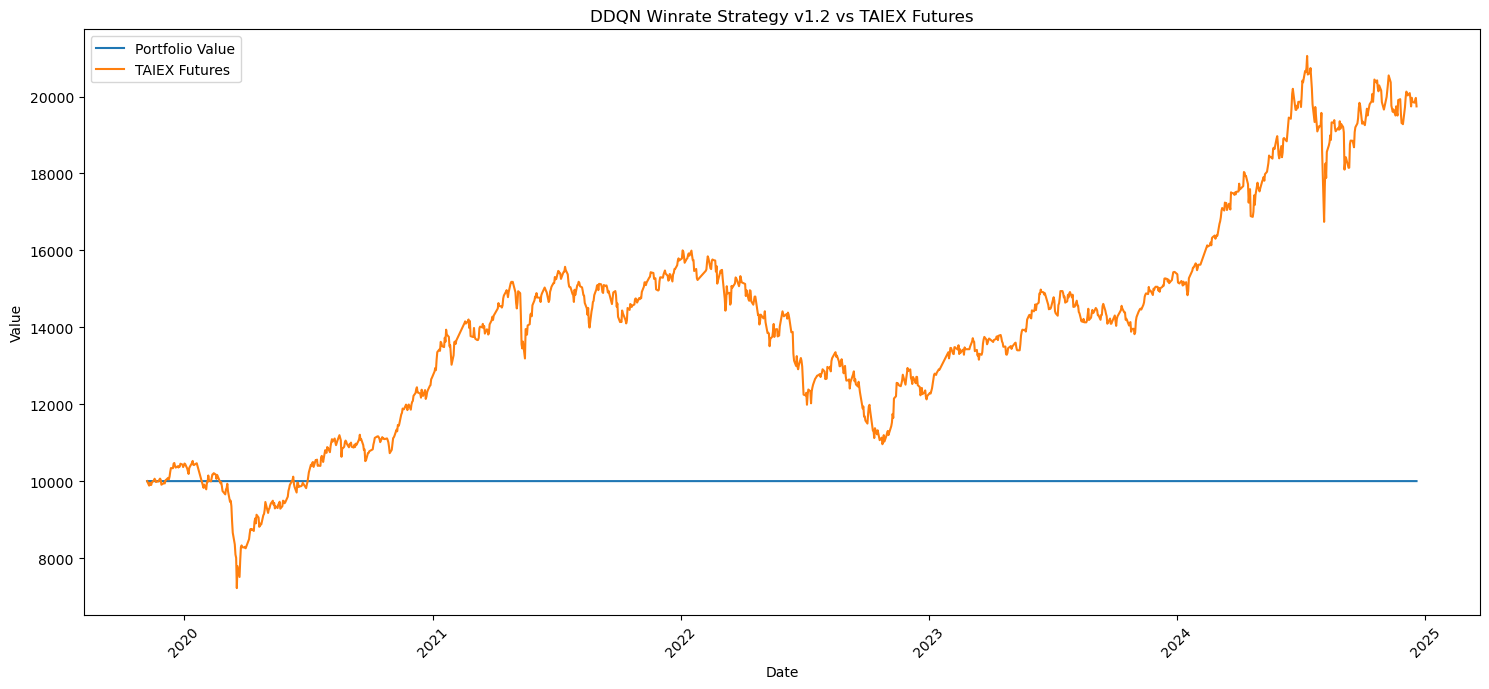


Winrate Strategy Performance Metrics:
Total Return (%): 0.0000
Annualized Return (%): 0.0000
Sharpe Ratio: nan
Max Drawdown (%): 0.0000
Win Rate (%): 0.0000


C:\Users\user\AppData\Local\Temp\ipykernel_37964\606776661.py:356: RuntimeWarning: invalid value encountered in scalar divide
  sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()


In [89]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 優化超參數設置
        self.memory = deque(maxlen=2000)    # 增加記憶體大小
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.02             # 提高最小探索率
        self.epsilon_decay = 0.997          # 更慢的衰減
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA10'] = data['Close'].rolling(window=10).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 波動率與趨勢
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Trend'] = np.where(data['MA5'] > data['MA20'], 1, -1)
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    state = [
        row['Close'] / row['MA20'] - 1,     # 價格相對MA20的位置
        row['RSI'] / 100,                   # RSI標準化
        row['Basis_Z_Score'],               # 基差Z分數
        row['Volatility'],                  # 波動率
        row['MA5'] / row['MA20'] - 1,       # MA交叉狀態
        row['Trend_Strength'],              # 趨勢強度
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 改進的基本獎勵
    if position != "Cash":
        if return_value > 0:
            base_reward = 2.5 if (
                (action_name == "Buy" and row['MA5'] > row['MA20']) or
                (action_name == "Sell" and row['MA5'] < row['MA20'])
            ) else 2.0
        else:
            base_reward = -1.5
    else:
        base_reward = 0
    
    # 基差獎勵：更嚴格的條件
    basis_reward = 1.5 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # RSI獎勵：更嚴格的條件
    rsi_reward = 1.0 if (action_name == "Buy" and row['RSI'] < 35) or \
                      (action_name == "Sell" and row['RSI'] > 65) else 0
    
    # 趨勢強度獎勵
    trend_reward = 0.5 if row['Trend_Strength'] > 0.01 else 0
    
    # 持倉時間懲罰：更早開始懲罰
    time_penalty = -0.2 * (holding_days / 8) if holding_days > 8 else 0
    
    total_reward = base_reward + basis_reward + rsi_reward + trend_reward + time_penalty
    return np.clip(total_reward, -3, 3)  # 限制獎勵範圍

def run_ddqn(data, episodes=100):
    state_size = 7  # 更新狀態維度
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 150)  # 增加訓練樣本大小
        episode_data = data.iloc[start_idx:start_idx + 150]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 優化風險參數
    max_holding_days = 12    # 縮短最大持倉時間
    stop_loss = 0.015       # 更保守的止損
    take_profit = 0.02      # 更保守的止盈
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損和止盈檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 更嚴格的進場條件
        if action == 0 and position != "Long":  # Buy
            if (30 <= row['RSI'] <= 45 and                    # 更嚴格的RSI範圍
                row['Close'] > row['MA5'] and               # 價格>MA5
                row['MA5'] > row['MA20'] and               # MA5>MA20
                row['Basis_Z_Score'] < -1.5 and            # 更嚴格的基差條件
                row['Trend_Strength'] > 0.005):            # 確認趨勢強度
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (55 <= row['RSI'] <= 70 and                    # 更嚴格的RSI範圍
                row['Close'] < row['MA5'] and               # 價格<MA5
                row['MA5'] < row['MA20'] and               # MA5<MA20
                row['Basis_Z_Score'] > 1.5 and             # 更嚴格的基差條件
                row['Trend_Strength'] > 0.005):            # 確認趨勢強度
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        value = portfolio_values[data.index.get_loc(trade[1])]
        if trade[0] == "Buy":
            plt.scatter(trade[1], value, color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], value, color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], value, color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], value, color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], value, color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v1.2 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v1.2 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate v1.3 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [2:31:25<00:00, 90.85s/it]


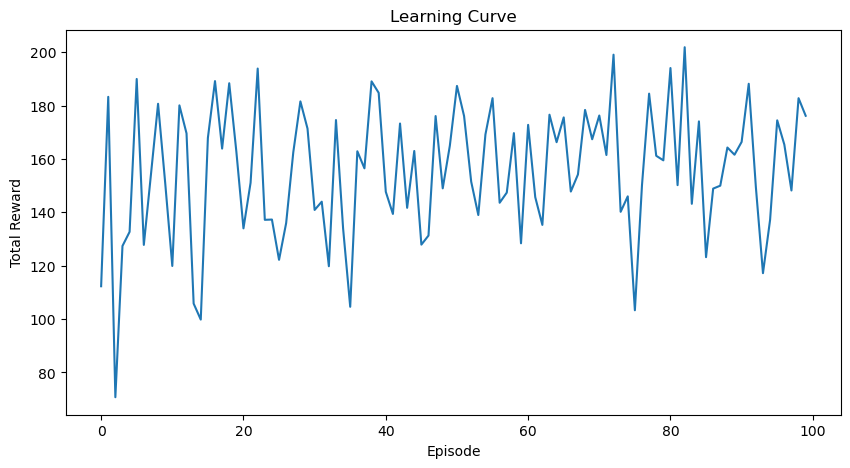


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-26 00:00:00	Buy		11618.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-09 00:00:00	StopLoss		11699.00		Exit Short
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-30 00:00:00	TakeProfit		11366.00		Exit Short
2020-02-17 00:00:00	Buy		11770.00		Enter Long
2020-02-24 00:00:00	StopLoss		11476.00		Exit Long
2020-05-04 00:00:00	Sell		10615.00		Enter Short
2020-05-07 00:00:00	StopLoss		10877.00		Exit Short
2020-06-15 00:00:00	Sell		11229.00		Enter Short
2020-06-16 00:00:00	StopLoss		11554.00		Exit Short
2020-06-18 00:00:00	Sell		11394.00		Enter Short
2020-07-01 00:00:00	StopLoss		11623.00		Exit Short
2020-09-21 00:00:00	Sell		12659.00		Enter Short
2020-09-24 00:00:00	TakeProfit		12166.00		Exit Short
2020-10-22 00:00:00	Sell		12837.00		Enter Short
2020-10-30 00:00:00	TakeProfit		12407.00		Exit Short
2020-12-17 00:00:00	Sell		14186.00		Enter Short
2020-12-30 00:00:

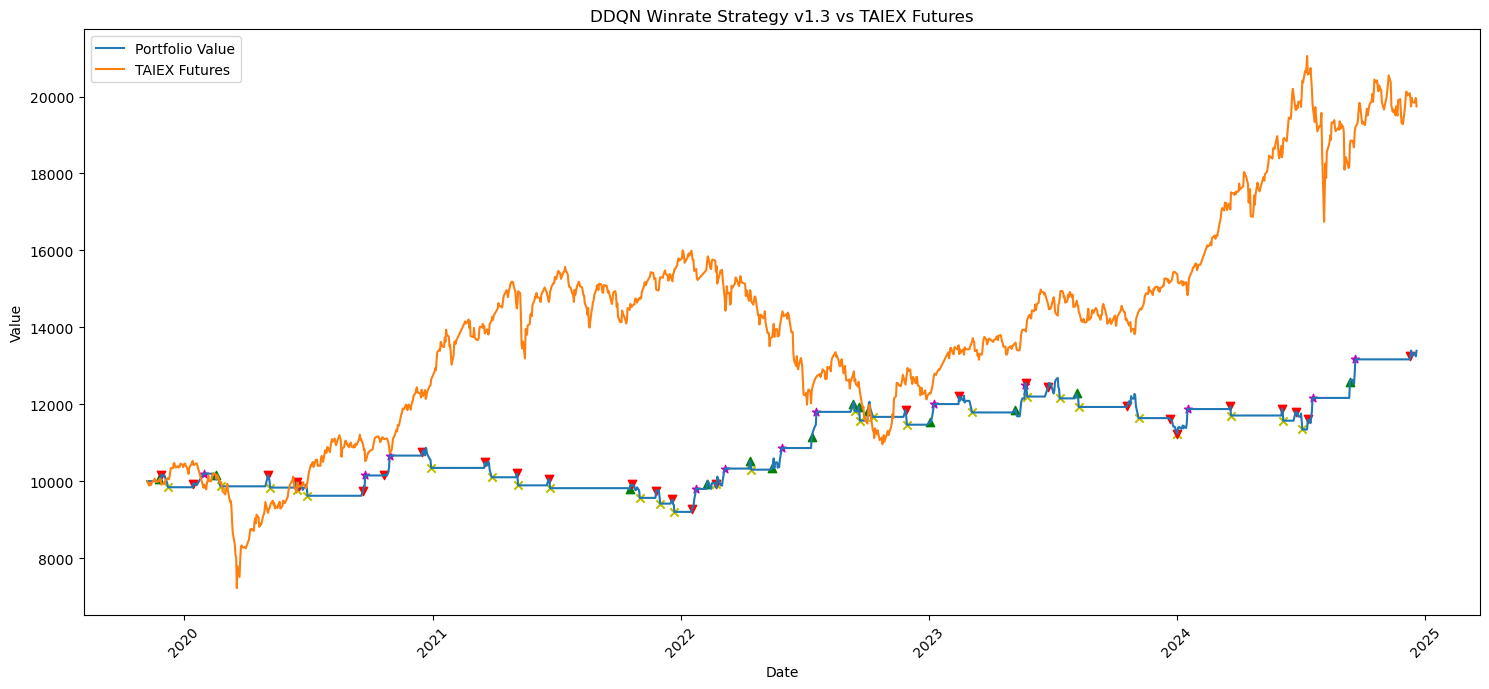


Winrate Strategy Performance Metrics:
Total Return (%): 33.8998
Annualized Return (%): 6.0868
Sharpe Ratio: 0.6750
Max Drawdown (%): 15.3451
Win Rate (%): 10.0402


In [91]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 基本超參數設置
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，計算技術指標"""
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """將市場數據轉換為狀態向量"""
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['MA5'] / row['MA20'] - 1,    # MA交叉狀態
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """計算獎勵"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.2) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.2) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 40) or \
                        (action_name == "Sell" and row['RSI'] > 60) else 0
    
    # 虧損控制獎勵
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def run_ddqn(data, episodes=100):
    state_size = 6
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 150)
        episode_data = data.iloc[start_idx:start_idx + 150]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 風險參數
    max_holding_days = 15
    stop_loss = 0.02
    take_profit = 0.03
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損和止盈檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行
        if action == 0 and position != "Long":  # Buy
            if (row['RSI'] < 55 and                      # 略微收緊RSI
                row['Close'] > row['MA5'] and           # 保持簡單的均線條件
                row['Basis_Z_Score'] < -1.2):           # 略微放寬基差條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (row['RSI'] > 45 and                      # 略微收緊RSI
                row['Close'] < row['MA5'] and           # 保持簡單的均線條件
                row['Basis_Z_Score'] > 1.2):            # 略微放寬基差條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        value = portfolio_values[data.index.get_loc(trade[1])]
        if trade[0] == "Buy":
            plt.scatter(trade[1], value, color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], value, color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], value, color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], value, color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], value, color='m', marker='*')
    
    plt.title('DDQN Winrate Strategy v1.3 vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate v1.3 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4153
訓練資料筆數: 2907
測試資料筆數: 1246
--------------------------------------------------

開始訓練 Winrate 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:42:04<00:00, 61.24s/it]


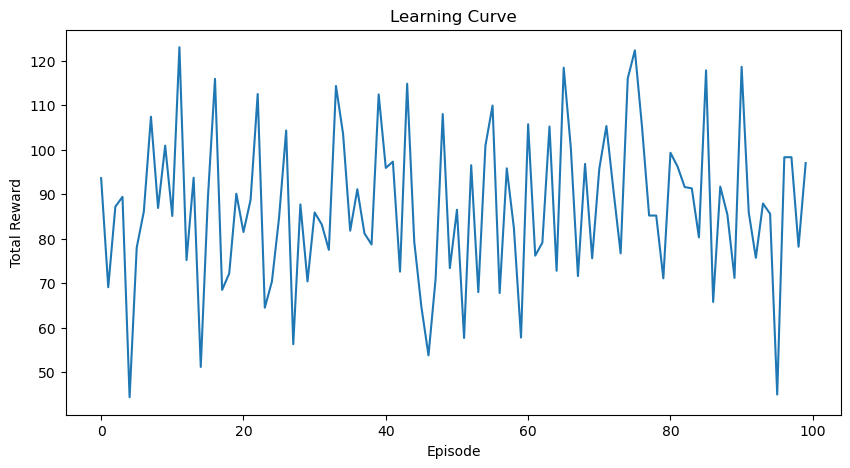


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-27 00:00:00	Buy		11647.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-05 00:00:00	Buy		11598.00		Enter Long
2019-12-23 00:00:00	Sell		12020.00		Enter Short
2020-01-09 00:00:00	Buy		11968.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-20 00:00:00	Buy		12111.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-02-05 00:00:00	Buy		11542.00		Enter Long
2020-02-26 00:00:00	TimeExit		11421.00		Exit Long
2020-03-05 00:00:00	Buy		11492.00		Enter Long
2020-03-06 00:00:00	StopLoss		11260.00		Exit Long
2020-03-24 00:00:00	Buy		9193.00		Enter Long
2020-04-16 00:00:00	TimeExit		10302.00		Exit Long
2020-04-22 00:00:00	Sell		10225.00		Enter Short
2020-04-27 00:00:00	StopLoss		10567.00		Exit Short
2020-05-04 00:00:00	Sell		10615.00		Enter Short
2020-05-05 00:00:00	Buy		10725.00		Enter Long
2020-05-22 00:00:00	Sell		10743.00		Enter Short


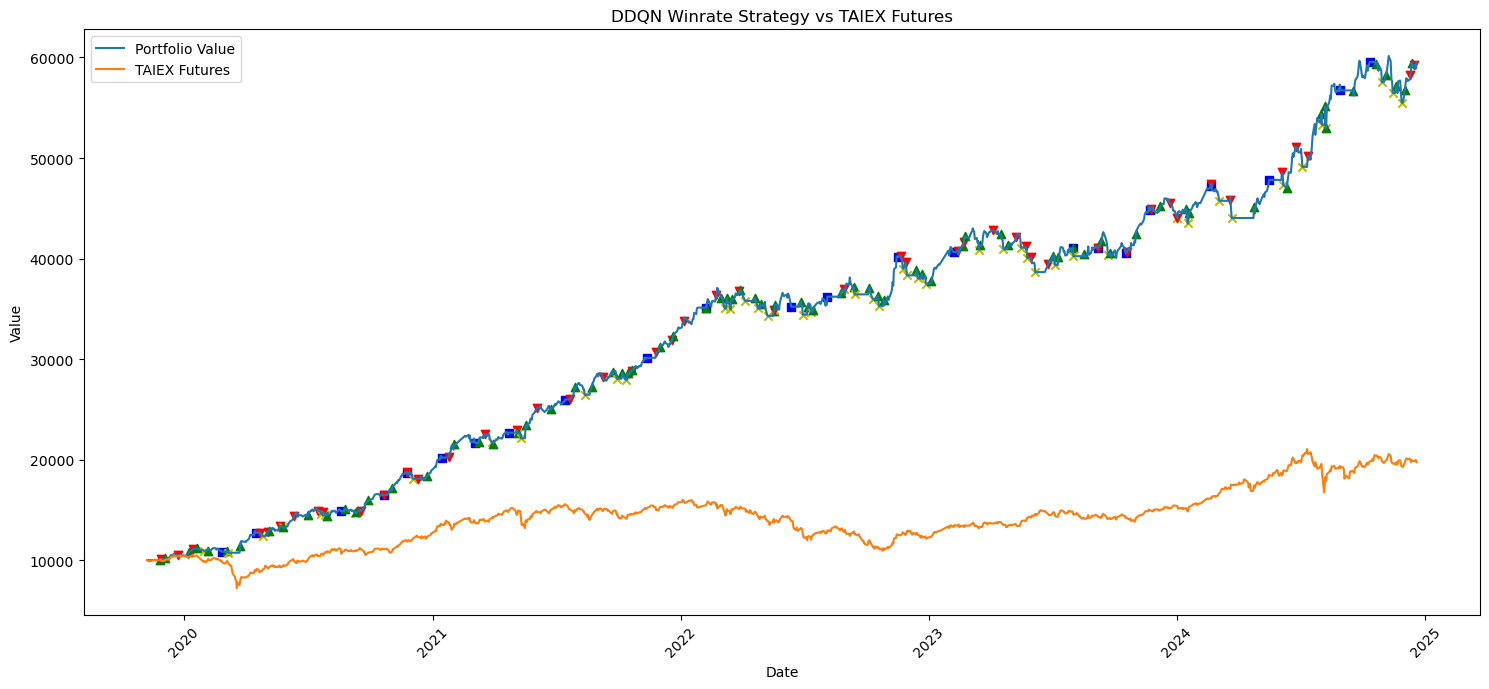


Winrate Strategy Performance Metrics:
Total Return (%): 495.3257
Annualized Return (%): 43.4887
Sharpe Ratio: 2.4339
Max Drawdown (%): 10.1165
Win Rate (%): 44.4177


In [93]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對winrate策略優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        # 創建網絡
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，計算技術指標"""
    try:
        data = pd.read_csv(file_path)
        
        # 檢查必要的列是否存在
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        # 確保所有價格列為數值類型
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        # 確保日期列格式
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # 計算RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 計算基差相關指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 計算回報率與波動率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """將市場數據轉換為狀態向量，針對winrate策略優化特徵"""
    state = [
        row['Close'] / row['MA20'] - 1,  # 價格相對MA20的位置
        row['RSI'] / 100,                # RSI標準化
        row['Basis_Z_Score'],            # 基差Z分數
        row['Volatility'],               # 波動率
        row['MA5'] / row['MA20'] - 1,    # MA交叉狀態
        (row['High'] - row['Low']) / row['Close']  # 當日波動範圍
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """針對winrate策略的獎勵函數"""
    return_value = row['Return']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 基本獎勵：重點關注勝率
    if position != "Cash":
        base_reward = 2.0 if return_value > 0 else -1.0
    else:
        base_reward = 0
    
    # 基差配合獎勵
    basis_reward = 1.0 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                        (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
    
    # 技術指標確認獎勵
    tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                        (action_name == "Sell" and row['RSI'] > 70) else 0
    
    # 虧損控制獎勵（鼓勵小虧損）
    loss_control = 0.3 if -0.01 <= return_value < 0 else 0
    
    return base_reward + basis_reward + tech_reward + loss_control

def run_ddqn(data, episodes=100):
    state_size = 6
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        # 每個episode使用部分數據
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # Winrate策略的風險控制參數
    max_holding_days = 15  # 縮短最大持倉時間
    stop_loss = 0.02      # 收緊止損
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損檢查
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
            holding_days = 0
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
            holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行 - 針對winrate策略優化的進場條件
        if action == 0 and position != "Long":  # Buy
            if row['RSI'] < 60 and row['Close'] > row['MA5']:  # 更保守的買入條件
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if row['RSI'] > 40 and row['Close'] < row['MA5']:  # 更保守的賣出條件
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        # 更新組合價值
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], color='b', marker='s')
    
    plt.title('DDQN Winrate Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置較小的批次大小和更快的學習頻率
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Winrate 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nWinrate Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4134
訓練資料筆數: 2893
測試資料筆數: 1241
--------------------------------------------------

開始訓練 Sharpe 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:40:46<00:00, 60.47s/it]


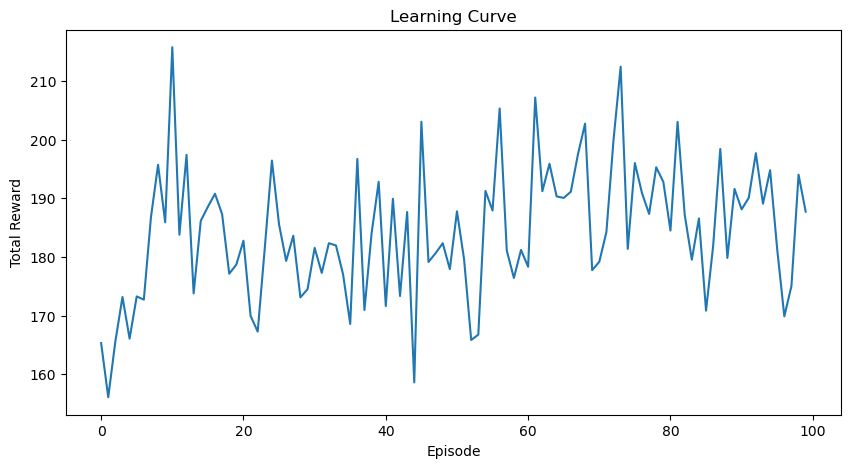


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2020-05-22 00:00:00	Sell		10743.00		Enter Short
2020-05-26 00:00:00	StopLoss		11027.00		Exit Short
2020-09-18 00:00:00	Sell		12835.00		Enter Short
2020-09-22 00:00:00	TakeProfit		12481.00		Exit Short
2020-10-27 00:00:00	Sell		12807.00		Enter Short
2020-10-29 00:00:00	TakeProfit		12504.00		Exit Short
2020-12-11 00:00:00	Sell		14236.00		Enter Short
2020-12-29 00:00:00	StopLoss		14466.00		Exit Short
2021-03-22 00:00:00	Sell		16140.00		Enter Short
2021-03-29 00:00:00	StopLoss		16485.00		Exit Short
2021-10-29 00:00:00	Sell		16945.00		Enter Short
2021-11-02 00:00:00	StopLoss		17255.00		Exit Short
2022-04-01 00:00:00	Sell		17554.00		Enter Short
2022-04-07 00:00:00	TakeProfit		17123.00		Exit Short
2022-06-07 00:00:00	Sell		16462.00		Enter Short
2022-06-13 00:00:00	TakeProfit		15993.00		Exit Short
2023-04-06 00:00:00	Sell		15760.00		Enter Short
2023-04-24 00:00:00	TimeExit		15623.00		Exit Short
2023-09

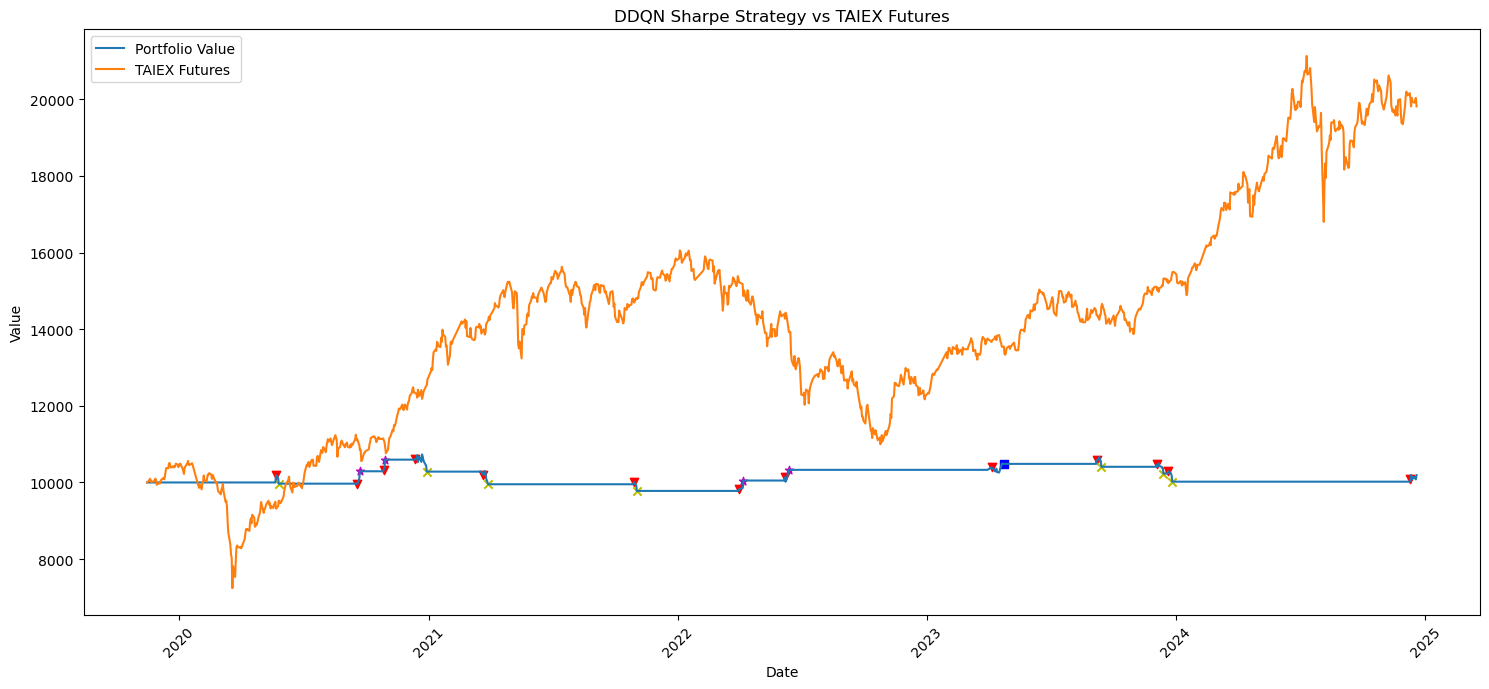


Sharpe Strategy Performance Metrics:
Total Return (%): 1.9142
Annualized Return (%): 0.3861
Sharpe Ratio: 0.1208
Max Drawdown (%): 8.8804
Win Rate (%): 3.2258


In [95]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對Sharpe策略優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.update_target_frequency = 5
        self.batch_size = 64
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        price_columns = ['Open', 'High', 'Low', 'Close']
        for col in price_columns:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 計算技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        
        # RSI
        delta = data['Close'].diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        data['RSI'] = 100 - (100 / (1 + rs))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 波動率與回報率
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
        data['Risk_Adjusted_Return'] = data['Return'] / data['Volatility']
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    # 針對Sharpe策略優化的特徵
    state = [
        row['Close'] / row['MA20'] - 1,        # 價格相對MA20的位置
        row['RSI'] / 100,                      # RSI標準化
        row['Basis_Z_Score'],                  # 基差Z分數
        row['Volatility'],                     # 波動率
        row['Volatility'] / row['Volatility_MA'], # 相對波動率
        row['MA5'] / row['MA20'] - 1,          # MA交叉狀態
        row['Risk_Adjusted_Return']            # 風險調整後收益
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """針對Sharpe策略的獎勵函數"""
    return_value = row['Return']
    volatility = row['Volatility']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 風險調整後的基本獎勵
    if position != "Cash":
        risk_adjusted_return = return_value / (volatility + 1e-6)  # 避免除以零
        base_reward = 2.0 * risk_adjusted_return if return_value > 0 else -1.0 * risk_adjusted_return
    else:
        base_reward = 0
    
    # 波動率獎勵：在低波動時期的正確交易獲得額外獎勵
    vol_reward = 0.5 if volatility < row['Volatility_MA'] else -0.2
    
    # 趨勢確認獎勵
    trend_reward = 0.5 if (action_name == "Buy" and row['MA5'] > row['MA20']) or \
                       (action_name == "Sell" and row['MA5'] < row['MA20']) else 0
    
    # RSI配合獎勵：收緊範圍以降低風險
    rsi_reward = 0.5 if (action_name == "Buy" and 35 <= row['RSI'] <= 45) or \
                      (action_name == "Sell" and 55 <= row['RSI'] <= 65) else 0
    
    # 基差配合獎勵：確保在合理範圍內交易
    basis_reward = 0.5 if (action_name == "Buy" and -2 < row['Basis_Z_Score'] < -0.5) or \
                        (action_name == "Sell" and 0.5 < row['Basis_Z_Score'] < 2) else 0
    
    return base_reward + vol_reward + trend_reward + rsi_reward + basis_reward

def run_ddqn(data, episodes=100):
    state_size = 7  # 更新狀態維度
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 針對Sharpe策略優化的風險參數
    max_holding_days = 12    # 較短的持倉時間
    stop_loss = 0.015       # 較小的止損
    take_profit = 0.02      # 較小的止盈
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 停損和止盈檢查
        if position == "Long":
            if row['Low'] < entry_price * (1 - stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
                holding_days = 0
            elif row['High'] > entry_price * (1 + take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
                holding_days = 0
        elif position == "Short":
            if row['High'] > entry_price * (1 + stop_loss):
                position = "Cash"
                portfolio_value *= (1 - stop_loss)
                trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
                holding_days = 0
            elif row['Low'] < entry_price * (1 - take_profit):
                position = "Cash"
                portfolio_value *= (1 + take_profit)
                trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
                holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 針對Sharpe策略優化的交易條件
        if action == 0 and position != "Long":  # Buy
            if (35 <= row['RSI'] <= 45 and                    # 更嚴格的RSI範圍
                row['Close'] > row['MA5'] and                # 價格在MA5上方
                row['Volatility'] < row['Volatility_MA'] and # 低波動時期
                -2 < row['Basis_Z_Score'] < -0.5):           # 合理的基差範圍
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (55 <= row['RSI'] <= 65 and                    # 更嚴格的RSI範圍
                row['Close'] < row['MA5'] and                # 價格在MA5下方
                row['Volatility'] < row['Volatility_MA'] and # 低波動時期
                0.5 < row['Basis_Z_Score'] < 2):             # 合理的基差範圍
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], label='TAIEX Futures')
    
    for trade in trades:
        value = portfolio_values[data.index.get_loc(trade[1])]
        if trade[0] == "Buy":
            plt.scatter(trade[1], value, color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], value, color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], value, color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], value, color='b', marker='s')
        elif trade[0] == "TakeProfit":
            plt.scatter(trade[1], value, color='m', marker='*')
    
    plt.title('DDQN Sharpe Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    
    sharpe_ratio = np.sqrt(252) * returns.mean() / returns.std()
    
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    
    win_rate = (returns > 0).mean() * 100
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Sharpe 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades:
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nSharpe Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4114
訓練資料筆數: 2879
測試資料筆數: 1235
--------------------------------------------------

開始訓練 Sharpe 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:36:51<00:00, 58.12s/it]


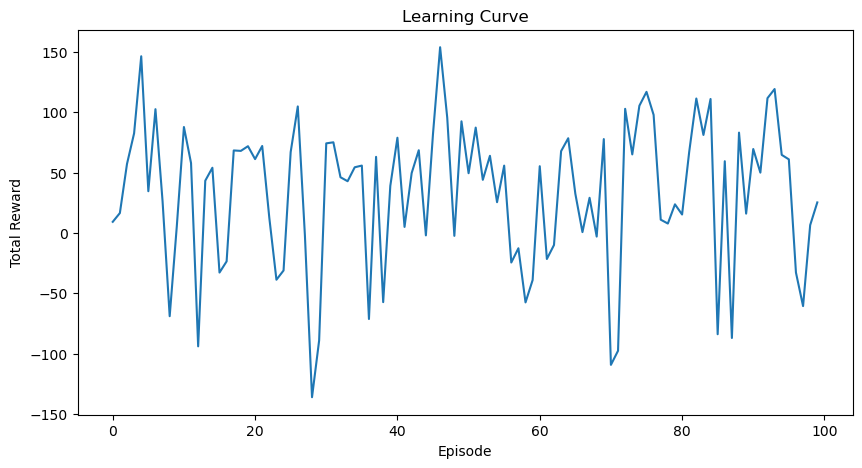


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-27 00:00:00	Buy		11647.00		Enter Long
2019-11-29 00:00:00	StopLoss		11462.00		Exit Long
2019-12-03 00:00:00	Sell		11524.00		Enter Short
2019-12-06 00:00:00	Buy		11612.00		Enter Long
2019-12-20 00:00:00	TimeExit		11979.00		Exit Long
2019-12-27 00:00:00	Buy		12097.00		Enter Long
2020-01-07 00:00:00	StopLoss		11816.00		Exit Long
2020-03-09 00:00:00	Sell		10950.00		Enter Short
2020-03-23 00:00:00	TimeExit		8688.00		Exit Short
2020-04-20 00:00:00	Buy		10476.00		Enter Long

總交易筆數: 204


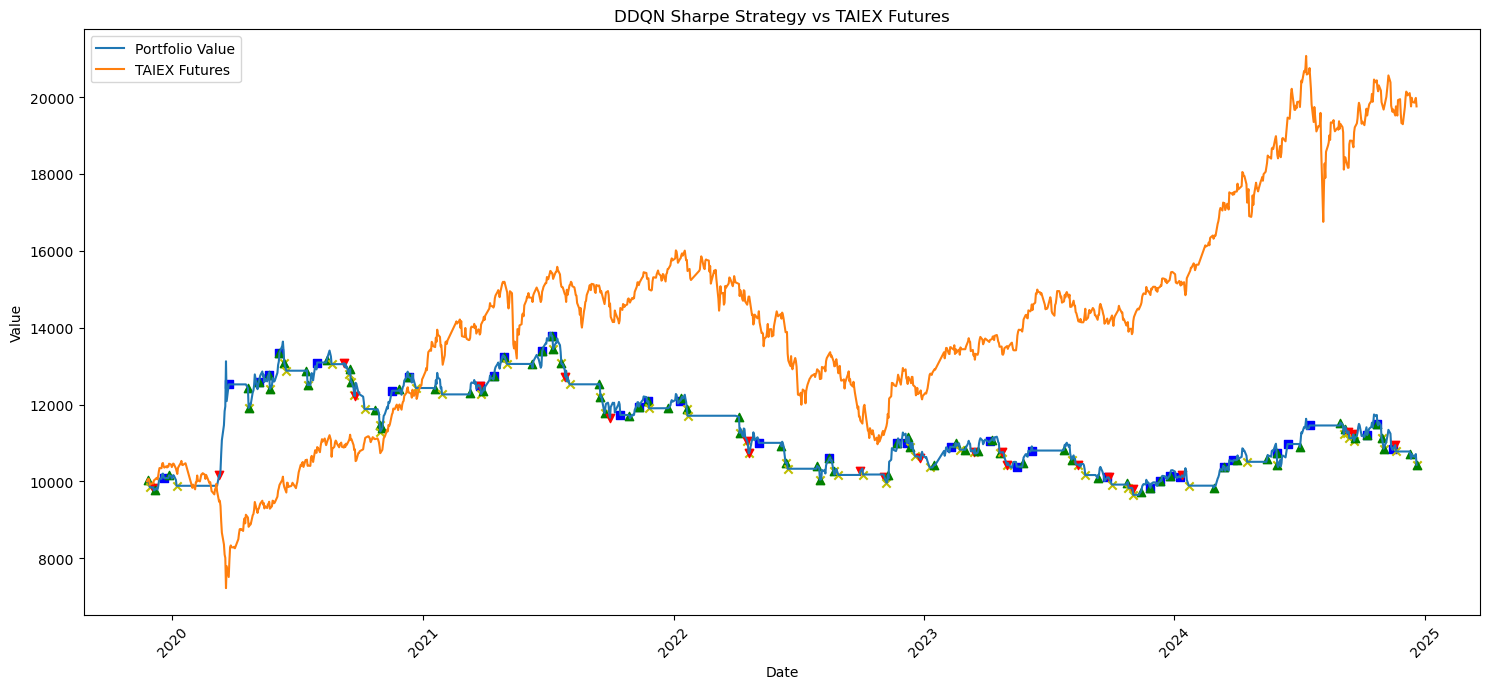


Sharpe Strategy Performance Metrics:
Total Return (%): 4.3330
Annualized Return (%): 0.8700
Sharpe Ratio: -0.0053
Sortino Ratio: -0.0070
Calmar Ratio: 0.0286
Max Drawdown (%): 30.4179
Win Rate (%): 28.1199


In [97]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對夏普比率優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.97  # 提高gamma以更注重長期收益
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.0005  # 降低學習率以減少波動
        self.update_target_frequency = 5
        self.batch_size = 128  # 增加批次大小以提高穩定性
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(64, activation='relu'),  # 增加網絡容量
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='huber', optimizer=Adam(learning_rate=self.learning_rate))  # 使用Huber loss提高穩定性
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，著重於風險調整指標的計算"""
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        for col in ['Open', 'High', 'Low', 'Close']:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 基本技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        data['MA60'] = data['Close'].rolling(window=60).mean()  # 加入長期均線
        
        # 波動率指標
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
        
        # 夏普指標相關計算
        risk_free_rate = 0.02 / 252  # 假設無風險利率2%
        data['Excess_Return'] = data['Return'] - risk_free_rate
        data['Rolling_Sharpe'] = (data['Excess_Return'].rolling(window=20).mean() / 
                                 data['Excess_Return'].rolling(window=20).std() * 
                                 np.sqrt(252))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """定義狀態空間，加入風險調整相關特徵"""
    state = [
        row['Close'] / row['MA20'] - 1,     # 價格相對MA20的位置
        row['MA5'] / row['MA20'] - 1,       # 短期趨勢
        row['MA20'] / row['MA60'] - 1,      # 中期趨勢
        row['Volatility'],                   # 當前波動率
        row['Volatility'] / row['Volatility_MA'] - 1,  # 波動率相對位置
        row['Rolling_Sharpe'],               # 滾動夏普比率
        row['Basis_Z_Score'],                # 基差Z分數
        row['Trend_Strength']                # 趨勢強度
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
    """針對夏普比率優化的獎勵函數"""
    return_value = row['Return']
    volatility = row['Volatility']
    actions = ["Buy", "Sell", "Hold"]
    action_name = actions[action]
    
    # 風險調整後收益
    risk_adjusted_return = return_value / (volatility if volatility > 0 else 1e-6)
    base_reward = 3.0 * risk_adjusted_return if position != "Cash" else 0
    
    # 趨勢配合獎勵
    trend_reward = 0.5 * row['Trend_Strength'] if position != "Cash" else 0
    
    # 波動率控制獎勵
    vol_reward = 0.5 if volatility < row['Volatility_MA'] and \
                      ((action_name == "Buy" and row['Basis_Z_Score'] < -1) or \
                       (action_name == "Sell" and row['Basis_Z_Score'] > 1)) else -0.1
    
    # 夏普比率獎勵
    sharpe_reward = 0.3 * row['Rolling_Sharpe'] if position != "Cash" else 0
    
    total_reward = base_reward + trend_reward + vol_reward + sharpe_reward
    
    # 懲罰過度交易
    if action != 2 and holding_days < 5:  # 2為Hold動作
        total_reward *= 0.8
    
    return total_reward

def run_ddqn(data, episodes=100):
    state_size = 8  # 更新狀態空間大小
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
    position = "Cash"
    portfolio_value = initial_capital = 10000
    portfolio_values = [portfolio_value]
    trades = []
    entry_price = 0
    holding_days = 0
    
    # 風險控制參數
    max_holding_days = 10  # 控制持倉時間
    stop_loss = 0.015     # 嚴格的止損
    
    for i in range(1, len(data)):
        row = data.iloc[i]
        state = define_state(row)
        action = agent.act(state, training=False)
        return_value = row['Return']
        
        if position != "Cash":
            holding_days += 1
        
        # 止損檢查
        if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
            holding_days = 0
        elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
            position = "Cash"
            portfolio_value *= (1 - stop_loss)
            trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
            holding_days = 0
        
        # 最大持倉時間檢查
        if holding_days >= max_holding_days and position != "Cash":
            trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
            portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
            position = "Cash"
            holding_days = 0
        
        # 交易執行 - 加入風險控制條件
        if action == 0 and position != "Long":  # Buy
            if (row['Volatility'] < row['Volatility_MA'] and 
                row['Rolling_Sharpe'] > 0 and 
                abs(row['Basis_Z_Score']) < 2):
                position = "Long"
                entry_price = row['Close']
                trades.append(("Buy", row.name, row['Close'], "Enter Long"))
                holding_days = 0
        elif action == 1 and position != "Short":  # Sell
            if (row['Volatility'] < row['Volatility_MA'] and 
                row['Rolling_Sharpe'] < 0 and 
                abs(row['Basis_Z_Score']) < 2):
                position = "Short"
                entry_price = row['Close']
                trades.append(("Sell", row.name, row['Close'], "Enter Short"))
                holding_days = 0
        
        # 更新組合價值
        if position == "Long":
            portfolio_value *= (1 + return_value)
        elif position == "Short":
            portfolio_value *= (1 - return_value)
        
        portfolio_values.append(portfolio_value)
    
    return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], 
             label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='b', marker='s')
    
    plt.title('DDQN Sharpe Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    # 計算夏普比率相關指標
    risk_free_rate = 0.02 / 252  # 年化2%
    excess_returns = returns - risk_free_rate
    sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    
    # 其他績效指標
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    win_rate = (returns > 0).mean() * 100
    
    # 計算額外的風險調整指標
    sortino_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns[excess_returns < 0].std()
    calmar_ratio = annualized_return / max_drawdown if max_drawdown != 0 else float('inf')
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Calmar Ratio": calmar_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割數據
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Sharpe 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades[:10]:  # 只顯示前10筆交易
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nSharpe Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4114
訓練資料筆數: 2879
測試資料筆數: 1235
--------------------------------------------------

開始訓練 Sharpe 策略:


Training Progress: 100%|███████████████████████████████████████████████████████████| 100/100 [1:38:16<00:00, 58.97s/it]


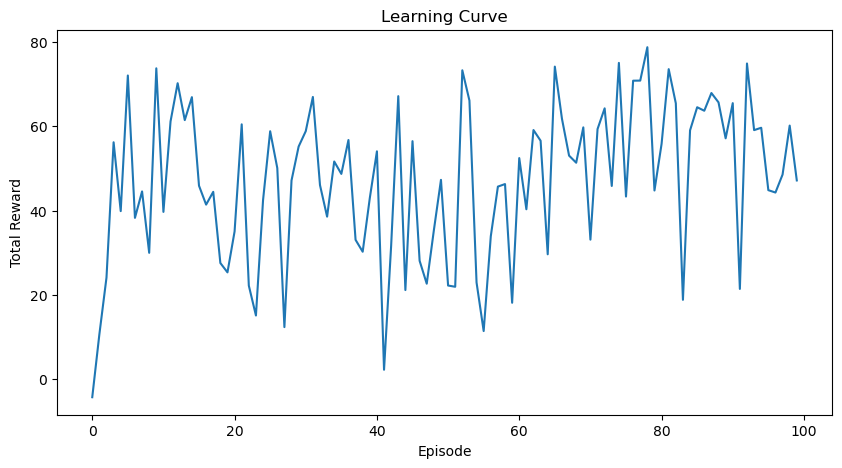


交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-27 00:00:00	Buy		11647.00		Enter Long
2019-11-29 00:00:00	StopLoss		11462.00		Exit Long
2019-12-09 00:00:00	Buy		11671.00		Enter Long
2019-12-13 00:00:00	TakeProfit		12007.00		Exit Long
2019-12-16 00:00:00	Buy		11961.00		Enter Long
2019-12-26 00:00:00	TimeExit		12009.00		Exit Long
2019-12-26 00:00:00	Buy		12009.00		Enter Long
2020-01-07 00:00:00	StopLoss		11816.00		Exit Long
2020-04-15 00:00:00	Buy		10450.00		Enter Long
2020-04-16 00:00:00	StopLoss		10161.00		Exit Long

總交易筆數: 362


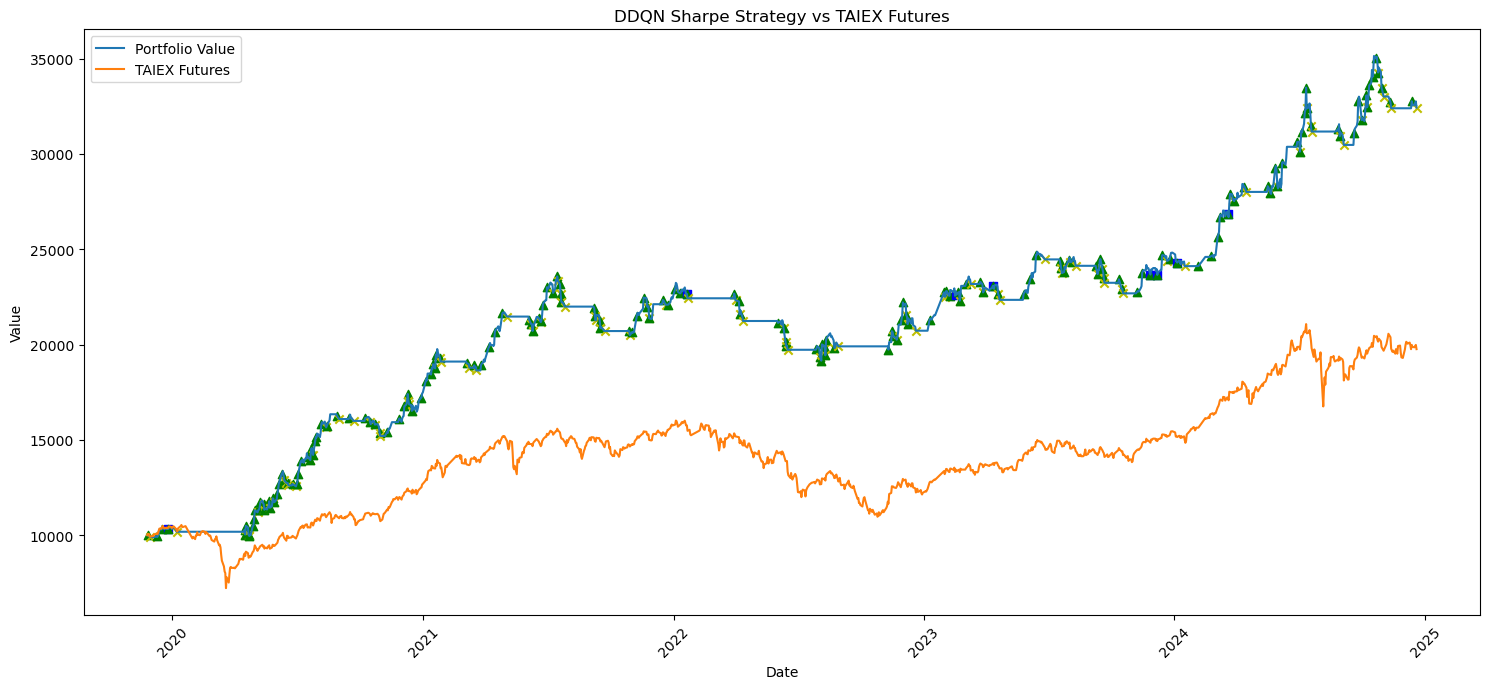


Sharpe Strategy Performance Metrics:
Total Return (%): 224.2753
Annualized Return (%): 27.1557
Sharpe Ratio: 1.5161
Sortino Ratio: 2.5896
Calmar Ratio: 1.4490
Max Drawdown (%): 18.7409
Win Rate (%): 27.1475


In [99]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        
        # 針對夏普比率優化的超參數
        self.memory = deque(maxlen=1000)
        self.gamma = 0.97  # 提高gamma以更注重長期收益
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.0005  # 降低學習率以減少波動
        self.update_target_frequency = 5
        self.batch_size = 128  # 增加批次大小以提高穩定性
        
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.target_model.set_weights(self.model.get_weights())
        
    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(64, activation='relu'),  # 增加網絡容量
            Dense(32, activation='relu'),
            Dense(16, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='huber', optimizer=Adam(learning_rate=self.learning_rate))  # 使用Huber loss提高穩定性
        return model
    
    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())
    
    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))
    
    def act(self, state, training=True):
        if training and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = np.array(state).reshape(1, -1)
        act_values = self.model.predict(state, verbose=0)
        return np.argmax(act_values[0])
    
    def replay(self):
        if len(self.memory) < self.batch_size:
            return
        
        minibatch = random.sample(self.memory, self.batch_size)
        states = np.array([i[0] for i in minibatch])
        actions = np.array([i[1] for i in minibatch])
        rewards = np.array([i[2] for i in minibatch])
        next_states = np.array([i[3] for i in minibatch])
        dones = np.array([i[4] for i in minibatch])
        
        targets = self.model.predict(states, verbose=0)
        target_next = self.target_model.predict(next_states, verbose=0)
        
        for i in range(self.batch_size):
            if dones[i]:
                targets[i][actions[i]] = rewards[i]
            else:
                targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
        
        self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
    """預處理數據，著重於風險調整指標的計算"""
    try:
        data = pd.read_csv(file_path)
        
        required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
        for col in required_columns:
            if col not in data.columns:
                raise ValueError(f"缺少必要的列: {col}")
        
        for col in ['Open', 'High', 'Low', 'Close']:
            if data[col].dtype == 'object':
                data[col] = data[col].astype(str).str.replace(',', '').astype(float)
            else:
                data[col] = data[col].astype(float)
        
        data['Date'] = pd.to_datetime(data['Date'])
        data.set_index('Date', inplace=True)
        
        # 基本技術指標
        data['MA5'] = data['Close'].rolling(window=5).mean()
        data['MA20'] = data['Close'].rolling(window=20).mean()
        data['MA60'] = data['Close'].rolling(window=60).mean()  # 加入長期均線
        
        # 波動率指標
        data['Return'] = data['Close'].pct_change()
        data['Volatility'] = data['Return'].rolling(window=20).std()
        data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
        
        # 夏普指標相關計算
        risk_free_rate = 0.02 / 252  # 假設無風險利率2%
        data['Excess_Return'] = data['Return'] - risk_free_rate
        data['Rolling_Sharpe'] = (data['Excess_Return'].rolling(window=20).mean() / 
                                 data['Excess_Return'].rolling(window=20).std() * 
                                 np.sqrt(252))
        
        # 基差指標
        if 'Basis' not in data.columns:
            data['Basis'] = data['Close'] - data['Open']
        data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
        data['Basis_STD'] = data['Basis'].rolling(window=20).std()
        data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
        
        # 趨勢強度
        data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
        
        # 去除NaN值
        data = data.dropna()
        
        return data
        
    except Exception as e:
        print(f"數據預處理錯誤: {str(e)}")
        return None

def define_state(row):
    """定義狀態空間，加入風險調整相關特徵"""
    state = [
        row['Close'] / row['MA20'] - 1,     # 價格相對MA20的位置
        row['MA5'] / row['MA20'] - 1,       # 短期趨勢
        row['MA20'] / row['MA60'] - 1,      # 中期趨勢
        row['Volatility'],                   # 當前波動率
        row['Volatility'] / row['Volatility_MA'] - 1,  # 波動率相對位置
        row['Rolling_Sharpe'],               # 滾動夏普比率
        row['Basis_Z_Score'],                # 基差Z分數
        row['Trend_Strength']                # 趨勢強度
    ]
    return np.array(state)

def calculate_reward(action, row, position, holding_days):
   """優化後的獎勵函數，著重風險調整"""
   return_value = row['Return'] 
   volatility = row['Volatility']
   actions = ["Buy", "Sell", "Hold"]
   action_name = actions[action]
   
   # 基礎風險調整收益
   risk_adjusted_return = return_value / (volatility if volatility > 0 else 1e-6)
   base_reward = 1.5 * risk_adjusted_return if position != "Cash" else 0
   
   # 波動率控制項
   vol_penalty = -0.5 * (row['Volatility'] - row['Volatility_MA'])
   
   # 趨勢獎勵
   trend_reward = 0.3 * row['Trend_Strength'] if (
       (action_name == "Buy" and row['MA5'] > row['MA20']) or 
       (action_name == "Sell" and row['MA5'] < row['MA20'])
   ) else 0
   
   # 持倉時間獎勵
   holding_reward = 0.1 * min(holding_days, 5) if position != "Cash" else 0
   
   # 加入風險管理獎勵
   risk_reward = 0.2 if (
       row['Volatility'] < row['Volatility_MA'] and 
       abs(row['Basis_Z_Score']) < 1.5
   ) else -0.1
   
   total_reward = (
       base_reward + 
       vol_penalty + 
       trend_reward + 
       holding_reward + 
       risk_reward
   )
   
   # 懲罰頻繁交易
   if action != 2 and holding_days < 3:
       total_reward *= 0.7
       
   return total_reward

def run_ddqn(data, episodes=100):
    state_size = 8  # 更新狀態空間大小
    action_size = 3
    agent = DDQNAgent(state_size, action_size)
    rewards_history = []
    
    for episode in tqdm(range(episodes), desc="Training Progress"):
        total_reward = 0
        position = "Cash"
        holding_days = 0
        
        start_idx = random.randint(0, len(data) - 100)
        episode_data = data.iloc[start_idx:start_idx + 100]
        
        state = define_state(episode_data.iloc[0])
        
        for i in range(1, len(episode_data)):
            row = episode_data.iloc[i]
            
            if position != "Cash":
                holding_days += 1
            
            action = agent.act(state)
            
            if action == 0:  # Buy
                if position != "Long":
                    position = "Long"
                    holding_days = 0
            elif action == 1:  # Sell
                if position != "Short":
                    position = "Short"
                    holding_days = 0
            
            reward = calculate_reward(action, row, position, holding_days)
            next_state = define_state(row)
            done = (i == len(episode_data)-1)
            
            agent.remember(state, action, reward, next_state, done)
            total_reward += reward
            
            if len(agent.memory) >= agent.batch_size:
                agent.replay()
            
            state = next_state
            
            if i % agent.update_target_frequency == 0:
                agent.update_target_model()
        
        rewards_history.append(total_reward)
        
    return agent, rewards_history

def evaluate_strategy(agent, data):
   position = "Cash"
   portfolio_value = initial_capital = 10000
   portfolio_values = [portfolio_value]
   trades = []
   entry_price = 0
   holding_days = 0
   
   # 優化風險控制參數
   max_holding_days = 8 
   stop_loss = 0.01
   take_profit = 0.02
   
   for i in range(1, len(data)):
       row = data.iloc[i]
       state = define_state(row)
       action = agent.act(state, training=False)
       return_value = row['Return']
       
       if position != "Cash":
           holding_days += 1
       
       # 止損檢查
       if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
           position = "Cash"
           portfolio_value *= (1 - stop_loss)
           trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
           holding_days = 0
       elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
           position = "Cash"
           portfolio_value *= (1 - stop_loss)
           trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
           holding_days = 0
           
       # 獲利了結檢查
       elif position == "Long" and row['High'] > entry_price * (1 + take_profit):
           position = "Cash"
           portfolio_value *= (1 + take_profit)
           trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
           holding_days = 0
       elif position == "Short" and row['Low'] < entry_price * (1 - take_profit):
           position = "Cash"
           portfolio_value *= (1 + take_profit)
           trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
           holding_days = 0
       
       # 最大持倉時間檢查
       if holding_days >= max_holding_days and position != "Cash":
           trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
           portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
           position = "Cash"
           holding_days = 0
       
       # 交易執行 - 加入風險控制條件
       if action == 0 and position != "Long":  # Buy
           if (row['Volatility'] < row['Volatility_MA'] * 1.1 and 
               row['Rolling_Sharpe'] > -0.5 and 
               abs(row['Basis_Z_Score']) < 1.5 and
               row['MA5'] > row['MA20']):
               position = "Long"
               entry_price = row['Close']
               trades.append(("Buy", row.name, row['Close'], "Enter Long"))
               holding_days = 0
       elif action == 1 and position != "Short":  # Sell
           if (row['Volatility'] < row['Volatility_MA'] * 1.1 and 
               row['Rolling_Sharpe'] < 0.5 and 
               abs(row['Basis_Z_Score']) < 1.5 and
               row['MA5'] < row['MA20']):
               position = "Short"
               entry_price = row['Close']
               trades.append(("Sell", row.name, row['Close'], "Enter Short"))
               holding_days = 0
       
       # 更新組合價值
       if position == "Long":
           portfolio_value *= (1 + return_value)
       elif position == "Short":
           portfolio_value *= (1 - return_value)
       
       portfolio_values.append(portfolio_value)
   
   return portfolio_values, trades

def plot_results(data, portfolio_values, trades):
    plt.figure(figsize=(15, 7))
    plt.plot(data.index, portfolio_values, label='Portfolio Value')
    plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], 
             label='TAIEX Futures')
    
    for trade in trades:
        if trade[0] == "Buy":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='g', marker='^')
        elif trade[0] == "Sell":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='r', marker='v')
        elif trade[0] == "StopLoss":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='y', marker='x')
        elif trade[0] == "TimeExit":
            plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                       color='b', marker='s')
    
    plt.title('DDQN Sharpe Strategy vs TAIEX Futures')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_learning_curve(rewards_history):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards_history)
    plt.title('Learning Curve')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
    returns = pd.Series(portfolio_values).pct_change().dropna()
    benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
    
    # 計算夏普比率相關指標
    risk_free_rate = 0.02 / 252  # 年化2%
    excess_returns = returns - risk_free_rate
    sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
    
    # 其他績效指標
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
    annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
    max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
    win_rate = (returns > 0).mean() * 100
    
    # 計算額外的風險調整指標
    sortino_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns[excess_returns < 0].std()
    calmar_ratio = annualized_return / max_drawdown if max_drawdown != 0 else float('inf')
    
    return {
        "Total Return (%)": total_return,
        "Annualized Return (%)": annualized_return * 100,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Calmar Ratio": calmar_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Win Rate (%)": win_rate
    }

if __name__ == "__main__":
    # 設置GPU記憶體增長
    physical_devices = tf.config.list_physical_devices('GPU')
    if len(physical_devices) > 0:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
    
    # 設置TensorFlow配置
    tf.config.run_functions_eagerly(False)
    
    file_path = "TX_daily_1220.csv"
    data = preprocess_data(file_path)

    if data is not None:
        # 7:3分割數據
        split_ratio = 0.7
        split_index = int(len(data) * split_ratio)
        train_data = data[:split_index]
        test_data = data[split_index:]

        print("\n資料集大小:")
        print(f"總資料筆數: {len(data)}")
        print(f"訓練資料筆數: {len(train_data)}")
        print(f"測試資料筆數: {len(test_data)}")
        print("-" * 50)

        print("\n開始訓練 Sharpe 策略:")
        trained_agent, rewards_history = run_ddqn(train_data)
        plot_learning_curve(rewards_history)
        
        portfolio_values, trades = evaluate_strategy(trained_agent, test_data)
        
        print("\n交易明細:")
        print("時間\t\t\t類型\t\t價格\t\t說明")
        print("-" * 70)
        for trade in trades[:10]:  # 只顯示前10筆交易
            print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
        print(f"\n總交易筆數: {len(trades)}")
        
        plot_results(test_data, portfolio_values, trades)
        
        benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
        metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
        
        print(f"\nSharpe Strategy Performance Metrics:")
        for key, value in metrics.items():
            print(f"{key}: {value:.4f}")


資料集大小:
總資料筆數: 4114
訓練資料筆數: 2879
測試資料筆數: 1235
--------------------------------------------------

開始訓練 Profit 策略:


Training Profit Strategy: 100%|████████████████████████████████████████████████████| 100/100 [1:36:56<00:00, 58.17s/it]


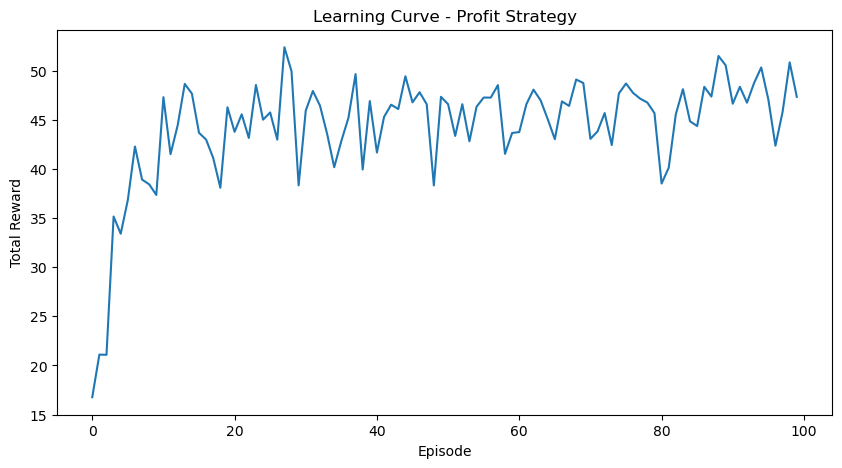


開始訓練 Winrate 策略:


Training Winrate Strategy: 100%|███████████████████████████████████████████████████| 100/100 [1:37:52<00:00, 58.73s/it]


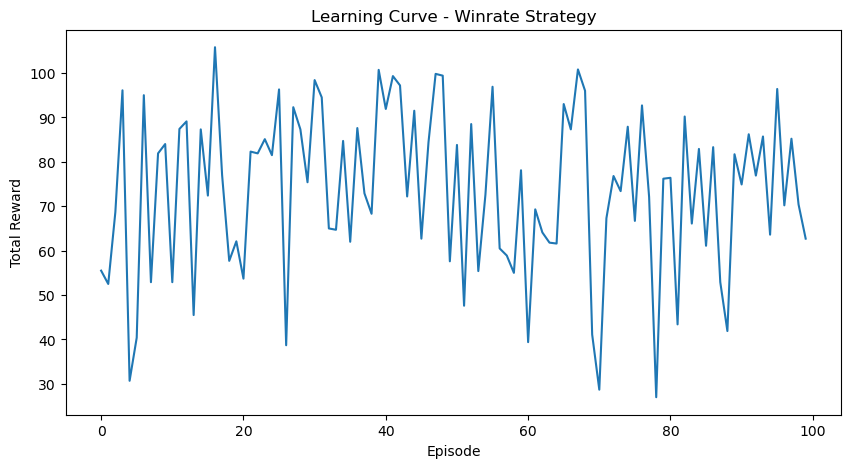


開始訓練 Sharpe 策略:


Training Sharpe Strategy: 100%|████████████████████████████████████████████████████| 100/100 [1:38:04<00:00, 58.84s/it]


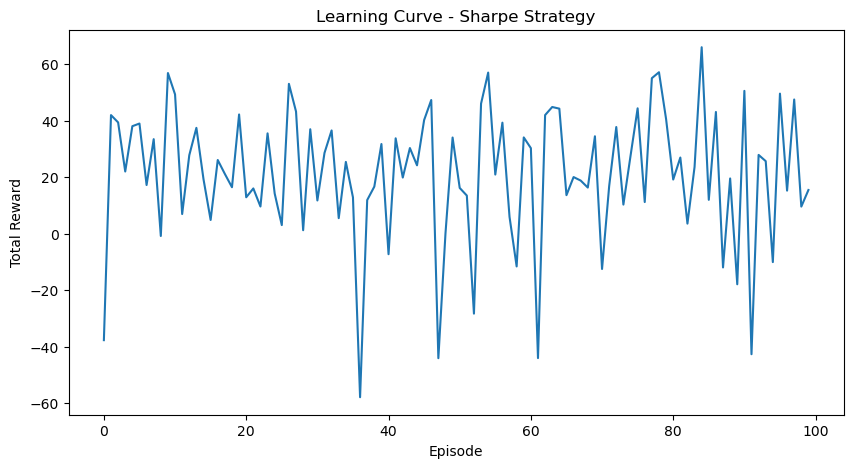


評估階段:

測試 Profit 策略:

交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-26 00:00:00	Buy		11618.00		Enter Long
2019-12-04 00:00:00	Sell		11503.00		Enter Short
2019-12-10 00:00:00	Buy		11625.00		Enter Long
2019-12-13 00:00:00	TakeProfit		12007.00		Exit Long
2019-12-31 00:00:00	Buy		11995.00		Enter Long
2020-01-08 00:00:00	StopLoss		11697.00		Exit Long
2020-01-08 00:00:00	Sell		11788.00		Enter Short
2020-01-10 00:00:00	StopLoss		12042.00		Exit Short
2020-01-15 00:00:00	Buy		12063.00		Enter Long
2020-01-30 00:00:00	StopLoss		11366.00		Exit Long
2020-01-30 00:00:00	Sell		11370.00		Enter Short
2020-02-05 00:00:00	StopLoss		11620.00		Exit Short
2020-02-05 00:00:00	Sell		11542.00		Enter Short
2020-02-12 00:00:00	StopLoss		11797.00		Exit Short
2020-02-12 00:00:00	Sell		11771.00		Enter Short
2020-02-19 00:00:00	Buy		11760.00		Enter Long
2020-02-24 00:00:00	StopLoss		11476.00		Exit Long
2020-02-24 00:00:00	Sell		11508.00		Enter Short
2020-03-02 

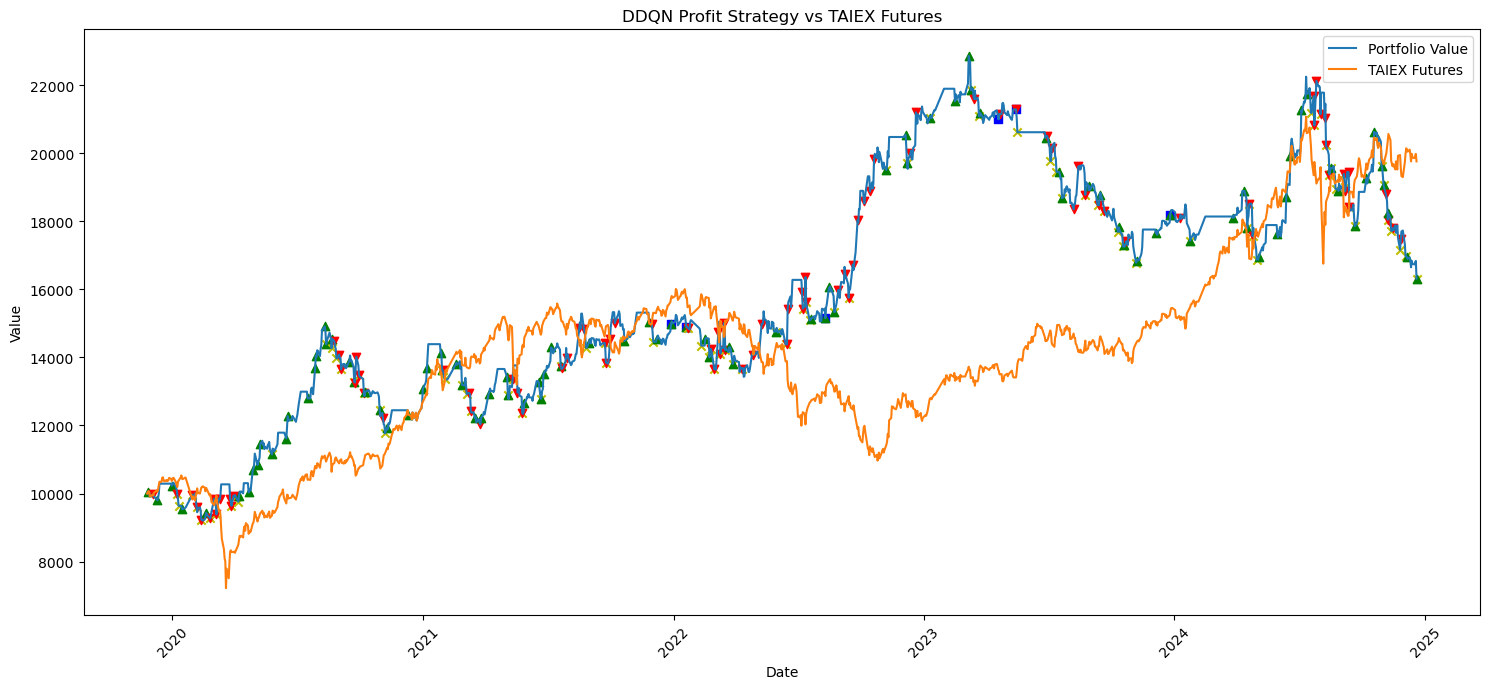


Profit Strategy Performance Metrics:
Total Return (%): 63.1468
Annualized Return (%): 10.5125
Sharpe Ratio: 0.4705
Sortino Ratio: 0.6727
Calmar Ratio: 0.3674
Max Drawdown (%): 28.6148
Win Rate (%): 40.5997

測試 Winrate 策略:

交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-26 00:00:00	Buy		11618.00		Enter Long
2019-11-29 00:00:00	Sell		11465.00		Enter Short
2019-12-06 00:00:00	Buy		11612.00		Enter Long
2019-12-13 00:00:00	TakeProfit		12007.00		Exit Long
2020-01-13 00:00:00	Buy		12117.00		Enter Long
2020-01-15 00:00:00	Sell		12063.00		Enter Short
2020-01-30 00:00:00	TakeProfit		11366.00		Exit Short
2020-02-17 00:00:00	Buy		11770.00		Enter Long
2020-02-20 00:00:00	Sell		11715.00		Enter Short
2020-02-27 00:00:00	TakeProfit		11237.00		Exit Short
2020-04-21 00:00:00	Sell		10198.00		Enter Short
2020-04-23 00:00:00	StopLoss		10402.00		Exit Short
2020-04-23 00:00:00	Sell		10292.00		Enter Short
2020-04-27 00:00:00	StopLoss		10567.00		Exit Short

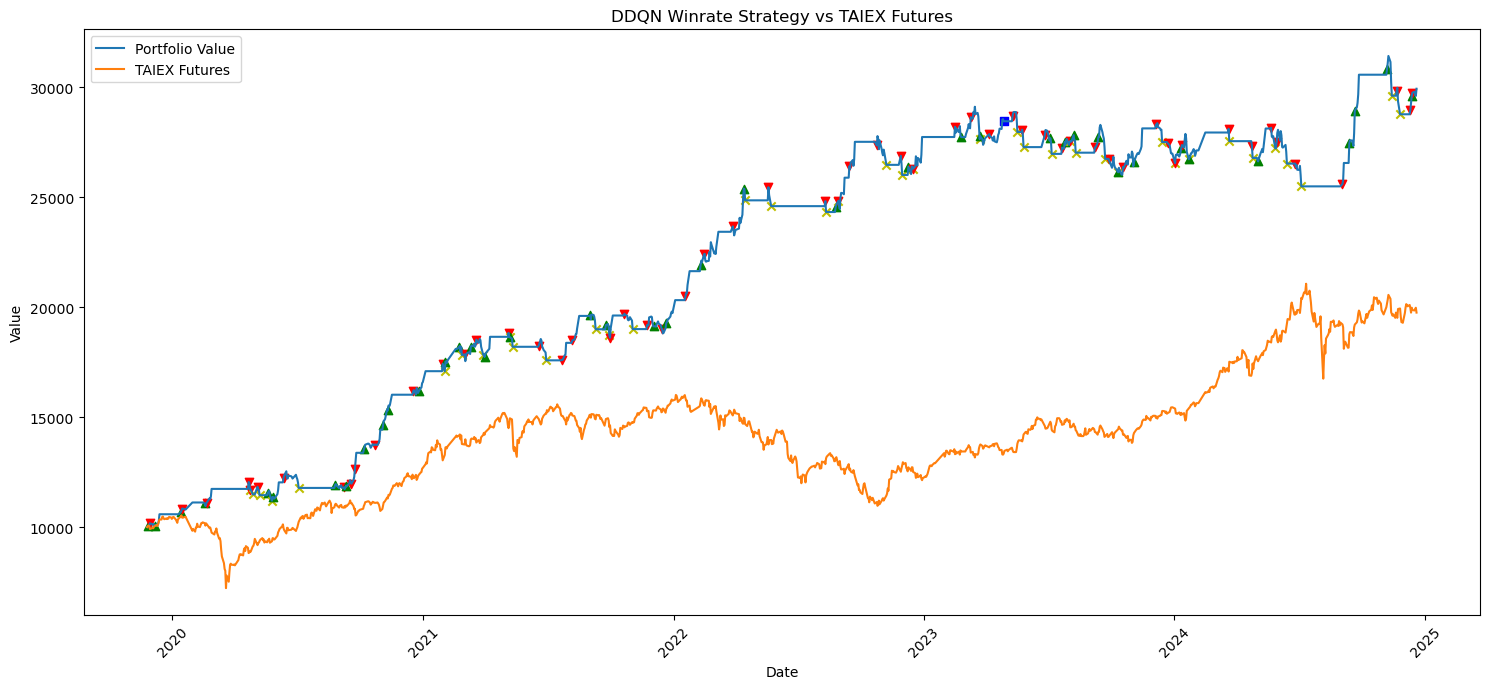


Winrate Strategy Performance Metrics:
Total Return (%): 199.4120
Annualized Return (%): 25.1010
Sharpe Ratio: 1.6437
Sortino Ratio: 2.6509
Calmar Ratio: 2.0182
Max Drawdown (%): 12.4372
Win Rate (%): 25.3647

測試 Sharpe 策略:

交易明細:
時間			類型		價格		說明
----------------------------------------------------------------------
2019-11-27 00:00:00	Buy		11647.00		Enter Long
2019-12-05 00:00:00	Sell		11598.00		Enter Short
2019-12-11 00:00:00	Buy		11706.00		Enter Long
2019-12-17 00:00:00	TakeProfit		12102.00		Exit Long
2019-12-17 00:00:00	Buy		12100.00		Enter Long
2020-01-07 00:00:00	StopLoss		11816.00		Exit Long
2020-02-24 00:00:00	Sell		11508.00		Enter Short
2020-03-02 00:00:00	TakeProfit		11005.00		Exit Short
2020-03-03 00:00:00	Sell		11324.00		Enter Short
2020-03-09 00:00:00	TakeProfit		10916.00		Exit Short
2020-04-15 00:00:00	Buy		10450.00		Enter Long
2020-04-16 00:00:00	StopLoss		10161.00		Exit Long
2020-04-16 00:00:00	Buy		10302.00		Enter Long
2020-04-17 00:00:00	TakeProfit		10669.00		Exit Lon

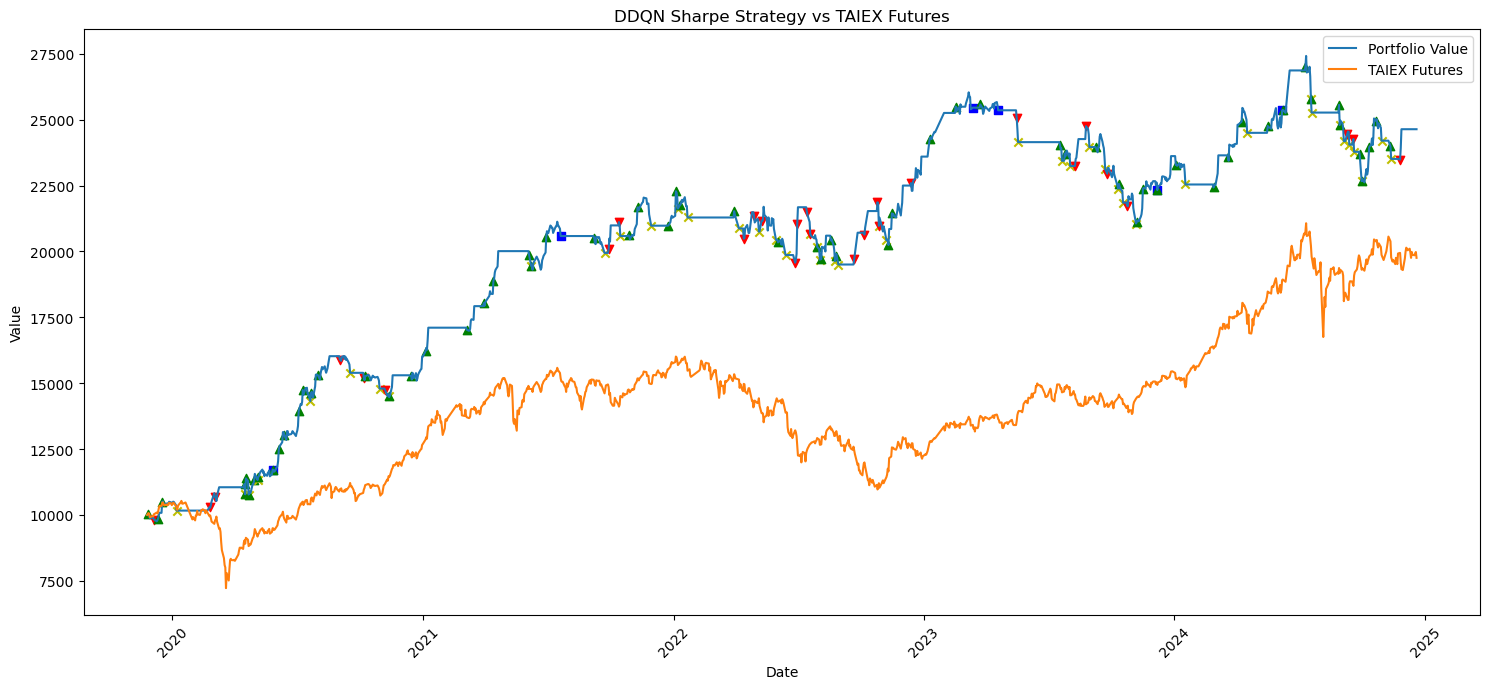


Sharpe Strategy Performance Metrics:
Total Return (%): 146.3782
Annualized Return (%): 20.2183
Sharpe Ratio: 1.1618
Sortino Ratio: 1.8654
Calmar Ratio: 1.0576
Max Drawdown (%): 19.1163
Win Rate (%): 26.8233

策略比較:

Strategy   Total Return    Sharpe Ratio    Max Drawdown    Win Rate       
----------------------------------------------------------------------
Profit     63.15           0.4705          28.61           40.60          
Winrate    199.41          1.6437          12.44           25.36          
Sharpe     146.38          1.1618          19.12           26.82          


In [111]:
# 基本套件導入
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from collections import deque
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

class DDQNAgent:
   def __init__(self, state_size, action_size):
       self.state_size = state_size
       self.action_size = action_size
       
       # 超參數
       self.memory = deque(maxlen=2000)
       self.gamma = 0.95
       self.epsilon = 1.0
       self.epsilon_min = 0.01
       self.epsilon_decay = 0.995
       self.learning_rate = 0.001
       self.update_target_frequency = 5
       self.batch_size = 64
       
       # 創建網絡
       self.model = self._build_model()
       self.target_model = self._build_model()
       self.target_model.set_weights(self.model.get_weights())
       
   def _build_model(self):
       model = Sequential([
           Input(shape=(self.state_size,)),
           Dense(64, activation='relu'),
           Dense(32, activation='relu'),
           Dense(16, activation='relu'),
           Dense(self.action_size, activation='linear')
       ])
       model.compile(loss='mse', optimizer=Adam(learning_rate=self.learning_rate))
       return model
   
   def update_target_model(self):
       self.target_model.set_weights(self.model.get_weights())
   
   def remember(self, state, action, reward, next_state, done):
       self.memory.append((state, action, reward, next_state, done))
   
   def act(self, state, training=True):
       if training and np.random.rand() <= self.epsilon:
           return random.randrange(self.action_size)
       state = np.array(state).reshape(1, -1)
       act_values = self.model.predict(state, verbose=0)
       return np.argmax(act_values[0])
   
   def replay(self):
       if len(self.memory) < self.batch_size:
           return
       
       minibatch = random.sample(self.memory, self.batch_size)
       states = np.array([i[0] for i in minibatch])
       actions = np.array([i[1] for i in minibatch])
       rewards = np.array([i[2] for i in minibatch])
       next_states = np.array([i[3] for i in minibatch])
       dones = np.array([i[4] for i in minibatch])
       
       targets = self.model.predict(states, verbose=0)
       target_next = self.target_model.predict(next_states, verbose=0)
       
       for i in range(self.batch_size):
           if dones[i]:
               targets[i][actions[i]] = rewards[i]
           else:
               targets[i][actions[i]] = rewards[i] + self.gamma * np.amax(target_next[i])
       
       self.model.fit(states, targets, epochs=1, batch_size=self.batch_size, verbose=0)
       
       if self.epsilon > self.epsilon_min:
           self.epsilon *= self.epsilon_decay

def preprocess_data(file_path):
   """預處理數據，著重於風險調整指標的計算"""
   try:
       data = pd.read_csv(file_path)
       
       required_columns = ['Date', 'Open', 'High', 'Low', 'Close']
       for col in required_columns:
           if col not in data.columns:
               raise ValueError(f"缺少必要的列: {col}")
       
       for col in ['Open', 'High', 'Low', 'Close']:
           if data[col].dtype == 'object':
               data[col] = data[col].astype(str).str.replace(',', '').astype(float)
           else:
               data[col] = data[col].astype(float)
       
       data['Date'] = pd.to_datetime(data['Date'])
       data.set_index('Date', inplace=True)
       
       # 基本技術指標
       data['MA5'] = data['Close'].rolling(window=5).mean()
       data['MA20'] = data['Close'].rolling(window=20).mean()
       data['MA60'] = data['Close'].rolling(window=60).mean()

       # 計算RSI
       delta = data['Close'].diff()
       gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
       loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
       rs = gain / loss
       data['RSI'] = 100 - (100 / (1 + rs))
       
       # 波動率指標
       data['Return'] = data['Close'].pct_change()
       data['Volatility'] = data['Return'].rolling(window=20).std()
       data['Volatility_MA'] = data['Volatility'].rolling(window=20).mean()
       
       # 夏普指標相關計算
       risk_free_rate = 0.02 / 252
       data['Excess_Return'] = data['Return'] - risk_free_rate
       data['Rolling_Sharpe'] = (data['Excess_Return'].rolling(window=20).mean() / 
                                data['Excess_Return'].rolling(window=20).std() * 
                                np.sqrt(252))

       # 基差指標
       if 'Basis' not in data.columns:
           data['Basis'] = data['Close'] - data['Open']
       data['Basis_MA'] = data['Basis'].rolling(window=20).mean()
       data['Basis_STD'] = data['Basis'].rolling(window=20).std()
       data['Basis_Z_Score'] = (data['Basis'] - data['Basis_MA']) / data['Basis_STD']
       
       # 趨勢強度
       data['Trend_Strength'] = abs(data['MA5'] - data['MA20']) / data['MA20']
       
       # 去除NaN值
       data = data.dropna()
       
       return data
       
   except Exception as e:
       print(f"數據預處理錯誤: {str(e)}")
       return None

def define_state(row):
   """定義狀態空間，加入風險調整相關特徵"""
   state = [
       row['Close'] / row['MA20'] - 1,     # 價格相對MA20的位置
       row['MA5'] / row['MA20'] - 1,       # 短期趨勢
       row['MA20'] / row['MA60'] - 1,      # 中期趨勢
       row['Volatility'],                   # 當前波動率
       row['Volatility'] / row['Volatility_MA'] - 1,  # 波動率相對位置
       row['Rolling_Sharpe'],               # 滾動夏普比率
       row['Basis_Z_Score'],                # 基差Z分數
       row['Trend_Strength']                # 趨勢強度
   ]
   return np.array(state)

def calculate_reward(action, row, position, holding_days, strategy_type='profit'):
   """統一基礎獎勵尺度的獎勵函數"""
   return_value = row['Return']
   actions = ["Buy", "Sell", "Hold"]
   action_name = actions[action]
   
   if strategy_type == 'profit':
       # 獲利導向獎勵
       base_reward = 2.0 * return_value if position != "Cash" else 0
       trend_reward = 0.5 if (action_name == "Buy" and row['MA5'] > row['MA20']) or \
                           (action_name == "Sell" and row['MA5'] < row['MA20']) else 0
       holding_reward = 0.002 * holding_days if base_reward > 0 else 0
       basis_reward = 0.3 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                           (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
       return base_reward + trend_reward + holding_reward + basis_reward
   
   elif strategy_type == 'winrate':
       # 勝率導向獎勵
       if position != "Cash":
           base_reward = 2.0 if return_value > 0 else -1.0
       else:
           base_reward = 0
           
       basis_reward = 0.5 if (action_name == "Buy" and row['Basis_Z_Score'] < -1.5) or \
                           (action_name == "Sell" and row['Basis_Z_Score'] > 1.5) else 0
       tech_reward = 0.5 if (action_name == "Buy" and row['RSI'] < 30) or \
                           (action_name == "Sell" and row['RSI'] > 70) else 0
       loss_control = 0.3 if -0.01 <= return_value < 0 else 0
       return base_reward + basis_reward + tech_reward + loss_control
   
   else:  # sharpe
       # 夏普比率導向獎勵
       volatility = row['Volatility']
       risk_adjusted_return = return_value / (volatility if volatility > 0 else 1e-6)
       base_reward = 2.0 * risk_adjusted_return if position != "Cash" else 0
       
       trend_reward = 0.3 * row['Trend_Strength'] if (
           (action_name == "Buy" and row['MA5'] > row['MA20']) or 
           (action_name == "Sell" and row['MA5'] < row['MA20'])
       ) else 0
       
       vol_reward = 0.5 if volatility < row['Volatility_MA'] else -0.2
       return base_reward + trend_reward + vol_reward

def run_ddqn(data, strategy_type='profit', episodes=100):
   state_size = 8
   action_size = 3
   agent = DDQNAgent(state_size, action_size)
   rewards_history = []
   
   for episode in tqdm(range(episodes), desc=f"Training {strategy_type.capitalize()} Strategy"):
       total_reward = 0
       position = "Cash"
       holding_days = 0
       
       start_idx = random.randint(0, len(data) - 100)
       episode_data = data.iloc[start_idx:start_idx + 100]
       
       state = define_state(episode_data.iloc[0])
       
       for i in range(1, len(episode_data)):
           row = episode_data.iloc[i]
           
           if position != "Cash":
               holding_days += 1
           
           action = agent.act(state)
           
           if action == 0:  # Buy
               if position != "Long":
                   position = "Long"
                   holding_days = 0
           elif action == 1:  # Sell
               if position != "Short":
                   position = "Short"
                   holding_days = 0
           
           reward = calculate_reward(action, row, position, holding_days, strategy_type)
           next_state = define_state(row)
           done = (i == len(episode_data)-1)
           
           agent.remember(state, action, reward, next_state, done)
           total_reward += reward
           
           if len(agent.memory) >= agent.batch_size:
               agent.replay()
           
           state = next_state
           
           if i % agent.update_target_frequency == 0:
               agent.update_target_model()
       
       rewards_history.append(total_reward)
       
   return agent, rewards_history

def evaluate_strategy(agent, data, strategy_type='profit'):
   position = "Cash"
   portfolio_value = initial_capital = 10000
   portfolio_values = [portfolio_value]
   trades = []
   entry_price = 0
   holding_days = 0
   
   # 統一的風險控制參數
   max_holding_days = 15
   stop_loss = 0.02
   take_profit = 0.03
   
   for i in range(1, len(data)):
       row = data.iloc[i]
       state = define_state(row)
       action = agent.act(state, training=False)
       return_value = row['Return']
       
       if position != "Cash":
           holding_days += 1
       
       # 統一的止損檢查
       if position == "Long" and row['Low'] < entry_price * (1 - stop_loss):
           position = "Cash"
           portfolio_value *= (1 - stop_loss)
           trades.append(("StopLoss", row.name, row['Low'], "Exit Long"))
           holding_days = 0
       elif position == "Short" and row['High'] > entry_price * (1 + stop_loss):
           position = "Cash"
           portfolio_value *= (1 - stop_loss)
           trades.append(("StopLoss", row.name, row['High'], "Exit Short"))
           holding_days = 0
       
       # 統一的止盈檢查
       elif position == "Long" and row['High'] > entry_price * (1 + take_profit):
           position = "Cash"
           portfolio_value *= (1 + take_profit)
           trades.append(("TakeProfit", row.name, row['High'], "Exit Long"))
           holding_days = 0
       elif position == "Short" and row['Low'] < entry_price * (1 - take_profit):
           position = "Cash"
           portfolio_value *= (1 + take_profit)
           trades.append(("TakeProfit", row.name, row['Low'], "Exit Short"))
           holding_days = 0
       
       # 統一的持倉時間檢查
       if holding_days >= max_holding_days and position != "Cash":
           trades.append(("TimeExit", row.name, row['Close'], f"Exit {position}"))
           portfolio_value *= (1 + return_value if position == "Long" else 1 - return_value)
           position = "Cash"
           holding_days = 0
           
       # 交易執行條件根據策略類型有所不同
       if action == 0 and position != "Long":  # Buy
           if should_enter_long(row, strategy_type):
               position = "Long"
               entry_price = row['Close']
               trades.append(("Buy", row.name, row['Close'], "Enter Long"))
               holding_days = 0
       elif action == 1 and position != "Short":  # Sell
           if should_enter_short(row, strategy_type):
               position = "Short"
               entry_price = row['Close']
               trades.append(("Sell", row.name, row['Close'], "Enter Short"))
               holding_days = 0
       
       # 更新組合價值
       if position == "Long":
           portfolio_value *= (1 + return_value)
       elif position == "Short":
           portfolio_value *= (1 - return_value)
       
       portfolio_values.append(portfolio_value)
   
   return portfolio_values, trades

def should_enter_long(row, strategy_type):
   if strategy_type == 'profit':
       return row['RSI'] < 70 and row['MA5'] > row['MA20']
   elif strategy_type == 'winrate':
       return row['RSI'] < 60 and row['Close'] > row['MA5']
   else:  # sharpe
       return (row['Volatility'] < row['Volatility_MA'] * 1.1 and 
               row['Rolling_Sharpe'] > -0.5 and 
               abs(row['Basis_Z_Score']) < 1.5 and
               row['MA5'] > row['MA20'])

def should_enter_short(row, strategy_type):
   if strategy_type == 'profit':
       return row['RSI'] > 30 and row['MA5'] < row['MA20']
   elif strategy_type == 'winrate':
       return row['RSI'] > 40 and row['Close'] < row['MA5']
   else:  # sharpe
       return (row['Volatility'] < row['Volatility_MA'] * 1.1 and 
               row['Rolling_Sharpe'] < 0.5 and 
               abs(row['Basis_Z_Score']) < 1.5 and
               row['MA5'] < row['MA20'])

def plot_results(data, portfolio_values, trades, strategy_type):
   plt.figure(figsize=(15, 7))
   plt.plot(data.index, portfolio_values, label='Portfolio Value')
   plt.plot(data.index, data['Close'] / data['Close'].iloc[0] * portfolio_values[0], 
            label='TAIEX Futures')
   
   for trade in trades:
       if trade[0] == "Buy":
           plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                      color='g', marker='^')
       elif trade[0] == "Sell":
           plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                      color='r', marker='v')
       elif trade[0] == "StopLoss":
           plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                      color='y', marker='x')
       elif trade[0] == "TimeExit":
           plt.scatter(trade[1], portfolio_values[data.index.get_loc(trade[1])], 
                      color='b', marker='s')
   
   plt.title(f'DDQN {strategy_type.capitalize()} Strategy vs TAIEX Futures')
   plt.xlabel('Date')
   plt.ylabel('Value')
   plt.legend()
   plt.xticks(rotation=45)
   plt.tight_layout()
   plt.show()

def plot_learning_curve(rewards_history, strategy_type):
   plt.figure(figsize=(10, 5))
   plt.plot(rewards_history)
   plt.title(f'Learning Curve - {strategy_type.capitalize()} Strategy')
   plt.xlabel('Episode')
   plt.ylabel('Total Reward')
   plt.show()

def calculate_performance_metrics(portfolio_values, benchmark_values):
   returns = pd.Series(portfolio_values).pct_change().dropna()
   benchmark_returns = pd.Series(benchmark_values).pct_change().dropna()
   
   risk_free_rate = 0.02 / 252
   excess_returns = returns - risk_free_rate
   sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std()
   
   total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0] * 100
   annualized_return = (1 + total_return/100) ** (252 / len(returns)) - 1
   max_drawdown = np.max(1 - pd.Series(portfolio_values) / pd.Series(portfolio_values).cummax())
   win_rate = (returns > 0).mean() * 100
   
   sortino_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns[excess_returns < 0].std()
   calmar_ratio = annualized_return / max_drawdown if max_drawdown != 0 else float('inf')
   
   return {
       "Total Return (%)": total_return,
       "Annualized Return (%)": annualized_return * 100,
       "Sharpe Ratio": sharpe_ratio,
       "Sortino Ratio": sortino_ratio,
       "Calmar Ratio": calmar_ratio,
       "Max Drawdown (%)": max_drawdown * 100,
       "Win Rate (%)": win_rate
   }

if __name__ == "__main__":
   # 設置GPU記憶體增長
   physical_devices = tf.config.list_physical_devices('GPU')
   if len(physical_devices) > 0:
       tf.config.experimental.set_memory_growth(physical_devices[0], True)
   
   # 設置TensorFlow配置
   tf.config.run_functions_eagerly(False)
   
   file_path = "TX_daily_1220.csv"
   data = preprocess_data(file_path)

   if data is not None:
       # 7:3分割數據
       split_ratio = 0.7
       split_index = int(len(data) * split_ratio)
       train_data = data[:split_index]
       test_data = data[split_index:]

       print("\n資料集大小:")
       print(f"總資料筆數: {len(data)}")
       print(f"訓練資料筆數: {len(train_data)}")
       print(f"測試資料筆數: {len(test_data)}")
       print("-" * 50)

       strategies = ['profit', 'winrate', 'sharpe']
       agents = {}
       results = {}

       # 訓練階段
       for strategy in strategies:
           print(f"\n開始訓練 {strategy.capitalize()} 策略:")
           agent, rewards = run_ddqn(train_data, strategy_type=strategy, episodes=100)
           agents[strategy] = agent
           results[strategy] = {
               'rewards': rewards,
               'strategy': strategy
           }
           plot_learning_curve(rewards, strategy)

       # 評估階段
       print("\n評估階段:")
       for strategy in strategies:
           print(f"\n測試 {strategy.capitalize()} 策略:")
           portfolio_values, trades = evaluate_strategy(agents[strategy], test_data, strategy)
           benchmark_values = test_data['Close'] / test_data['Close'].iloc[0] * portfolio_values[0]
           metrics = calculate_performance_metrics(portfolio_values, benchmark_values)
           
           results[strategy].update({
               'portfolio_values': portfolio_values,
               'trades': trades,
               'metrics': metrics
           })
           
           print("\n交易明細:")
           print("時間\t\t\t類型\t\t價格\t\t說明")
           print("-" * 70)
           for trade in trades:  # 顯示所有交易
               print(f"{trade[1]}\t{trade[0]}\t\t{trade[2]:.2f}\t\t{trade[3]}")
           print(f"\n總交易筆數: {len(trades)}")
           
           plot_results(test_data, portfolio_values, trades, strategy)
           print(f"\n{strategy.capitalize()} Strategy Performance Metrics:")
           for key, value in metrics.items():
               print(f"{key}: {value:.4f}")

       # 比較結果
       print("\n策略比較:")
       print("\n{:<10} {:<15} {:<15} {:<15} {:<15}".format(
           "Strategy", "Total Return", "Sharpe Ratio", "Max Drawdown", "Win Rate"))
       print("-" * 70)
       for strategy in strategies:
           metrics = results[strategy]['metrics']
           print("{:<10} {:<15.2f} {:<15.4f} {:<15.2f} {:<15.2f}".format(
               strategy.capitalize(),
               metrics['Total Return (%)'],
               metrics['Sharpe Ratio'],
               metrics['Max Drawdown (%)'],
               metrics['Win Rate (%)']
           ))